In [10]:
# ============================================================
# JUPYTER DASHBOARD:
# Cross-Exchange Perpetual Spread + Z-Score + StatArb Metrics
#
# Не использует Streamlit.
# Работает непосредственно в Jupyter Notebook.
#
# Возможности:
# - Поиск perpetual token/USDT на нескольких биржах.
# - График цен всех доступных бирж.
# - Выбор двух бирж чекбоксами с учётом порядка.
# - Абсолютный и процентный спред.
# - Rolling Z-score с бегунком window.
# - Hedge ratio, half-life, Hurst, correlation, crossings.
# ============================================================

from __future__ import annotations

from concurrent.futures import (
    ThreadPoolExecutor,
    as_completed,
)

import ccxt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import ipywidgets as widgets

from IPython.display import (
    HTML,
    clear_output,
    display,
)


# ============================================================
# 1. СПИСОК БИРЖ
# ============================================================

EXCHANGES = {
    "Binance USD-M": "binanceusdm",
    "Bybit": "bybit",
    "OKX": "okx",
    "Bitget": "bitget",
    "Gate.io": "gateio",
    "MEXC": "mexc",
    "KuCoin Futures": "kucoinfutures",
    "BingX": "bingx",
}


# ============================================================
# 2. ГЛОБАЛЬНОЕ СОСТОЯНИЕ ИНТЕРФЕЙСА
# ============================================================

STATE = {
    "token": None,
    "quote": "USDT",
    "timeframe": None,
    "limit": None,

    "markets": {},
    "series": {},

    "discovery_errors": {},
    "load_errors": {},

    "checkboxes": {},

    # Порядок выбора бирж:
    # первая отмеченная = Биржа 1;
    # вторая отмеченная = Биржа 2.
    "selected_order": [],
}


# ============================================================
# 3. CCXT: СОЗДАНИЕ БИРЖИ
# ============================================================

def make_exchange(exchange_id: str) -> ccxt.Exchange:
    """
    Создаёт CCXT-exchange для USDT perpetual swap.
    """
    exchange_class = getattr(
        ccxt,
        exchange_id,
    )

    exchange = exchange_class({
        "enableRateLimit": True,
        "timeout": 30_000,
        "options": {
            "defaultType": "swap",
        },
    })

    return exchange


# ============================================================
# 4. ПОИСК PERPETUAL-КОНТРАКТА
# ============================================================

def find_usdt_perpetual(
    exchange_name: str,
    exchange_id: str,
    token: str,
    quote: str = "USDT",
) -> tuple[str, dict]:
    """
    Ищет активный USDT-settled perpetual swap.

    Пример найденного CCXT-symbol:
        BDX/USDT:USDT
    """
    token = token.upper().strip()
    quote = quote.upper().strip()

    exchange = make_exchange(exchange_id)

    if not exchange.has.get("fetchOHLCV"):
        raise RuntimeError(
            "Биржа не поддерживает OHLCV."
        )

    exchange.load_markets()

    candidates = []

    for market in exchange.markets.values():
        if (
            market.get("active", True)
            and market.get("swap") is True
            and market.get("base") == token
            and market.get("quote") == quote
            and market.get("settle") == quote
        ):
            candidates.append(market)

    if not candidates:
        raise ValueError(
            f"{token}/{quote} perpetual не найден."
        )

    market = candidates[0]

    return exchange_name, {
        "exchange_id": exchange.id,
        "symbol": market["symbol"],
        "market_id": market["id"],
    }


# ============================================================
# 5. ЗАГРУЗКА ЗАКРЫТЫХ СВЕЧЕЙ
# ============================================================

def fetch_closed_ohlcv(
    exchange_name: str,
    exchange_id: str,
    symbol: str,
    timeframe: str,
    limit: int,
) -> tuple[str, pd.DataFrame]:
    """
    Возвращает DataFrame:

        timestamp
        datetime_utc
        close

    Незакрытая последняя свеча удаляется.
    """
    exchange = make_exchange(exchange_id)

    timeframe_ms = (
        exchange.parse_timeframe(timeframe)
        * 1000
    )

    since = (
        exchange.milliseconds()
        - (limit + 10) * timeframe_ms
    )

    ohlcv = exchange.fetch_ohlcv(
        symbol=symbol,
        timeframe=timeframe,
        since=since,
        limit=limit,
    )

    if not ohlcv:
        raise RuntimeError(
            "Биржа не вернула OHLCV."
        )

    df = pd.DataFrame(
        ohlcv,
        columns=[
            "timestamp",
            "open",
            "high",
            "low",
            "close",
            "volume",
        ],
    )

    # Удаляем текущую ещё незавершённую свечу.
    now_ms = exchange.milliseconds()

    df = df[
        df["timestamp"] + timeframe_ms <= now_ms
    ].copy()

    df["datetime_utc"] = pd.to_datetime(
        df["timestamp"],
        unit="ms",
        utc=True,
    )

    df = (
        df[
            [
                "timestamp",
                "datetime_utc",
                "close",
            ]
        ]
        .drop_duplicates(
            subset="timestamp",
            keep="last",
        )
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    if df.empty:
        raise RuntimeError(
            "После удаления незакрытой свечи "
            "не осталось данных."
        )

    return exchange_name, df


# ============================================================
# 6. ГРАФИК ВСЕХ ЦЕН
# ============================================================

def build_prices_figure(
    series: dict[str, pd.DataFrame],
    token: str,
    quote: str,
) -> go.Figure:
    """
    Один график цен для всех доступных бирж.
    """
    fig = go.Figure()

    colors = [
        "#00CC96",
        "#EF553B",
        "#636EFA",
        "#AB63FA",
        "#FFA15A",
        "#19D3F3",
        "#FF6692",
        "#B6E880",
    ]

    for index, (exchange_name, df) in enumerate(
        series.items()
    ):
        fig.add_trace(
            go.Scatter(
                x=df["datetime_utc"],
                y=df["close"],

                mode="lines",

                name=exchange_name,

                line=dict(
                    color=colors[index % len(colors)],
                    width=1.8,
                ),

                hovertemplate=(
                    f"<b>{exchange_name}</b><br>"
                    "Время: %{x}<br>"
                    f"Цена: %{{y:.10f}} {quote}"
                    "<extra></extra>"
                ),
            )
        )

    fig.update_layout(
        title=(
            f"{token}/{quote} perpetual — "
            f"цены на доступных биржах"
        ),

        template="plotly_dark",

        height=560,

        dragmode="pan",
        hovermode="x unified",

        margin=dict(
            l=80,
            r=30,
            t=70,
            b=60,
        ),

        legend=dict(
            orientation="h",
        ),

        xaxis=dict(
            title="Время, UTC",
            type="date",
            rangeslider=dict(
                visible=True,
            ),
        ),

        yaxis=dict(
            title=f"Цена, {quote}",
            zeroline=False,
        ),
    )

    return fig


# ============================================================
# 7. HURST EXPONENT
# ============================================================

def calculate_hurst_exponent(
    series: pd.Series,
    min_lag: int = 2,
    max_lag: int = 50,
) -> float:
    """
    Оценка Hurst exponent.

    Интерпретация:
        H < 0.5  -> tendency к mean reversion;
        H ≈ 0.5  -> случайное блуждание;
        H > 0.5  -> persistence / trend-like behaviour.

    Метод:
        Анализ роста std(x[t+lag] - x[t])
        на разных значениях lag.
    """
    x = np.asarray(
        series.dropna(),
        dtype=float,
    )

    if len(x) < 30:
        return np.nan

    max_lag = min(
        max_lag,
        len(x) // 2,
    )

    if max_lag <= min_lag:
        return np.nan

    lags = np.arange(
        min_lag,
        max_lag + 1,
    )

    tau = []

    valid_lags = []

    for lag in lags:
        diff = x[lag:] - x[:-lag]
        value = np.std(diff)

        if value > 0 and np.isfinite(value):
            tau.append(value)
            valid_lags.append(lag)

    if len(tau) < 5:
        return np.nan

    slope, _ = np.polyfit(
        np.log(valid_lags),
        np.log(tau),
        1,
    )

    # Для данной оценки H примерно равен slope.
    return float(slope)


# ============================================================
# 8. HALF-LIFE MEAN REVERSION
# ============================================================

def calculate_half_life(
    spread: pd.Series,
) -> float:
    """
    Оценивает half-life spread.

    Используется AR(1)-подобная регрессия:

        ΔS_t = alpha + beta * S_(t-1) + error

    Если beta < 0, есть возврат к среднему.

    Half-life:

        -ln(2) / beta

    Результат измеряется в свечах.

    Возвращает NaN, если устойчивый half-life
    корректно рассчитать нельзя.
    """
    x = np.asarray(
        spread.dropna(),
        dtype=float,
    )

    if len(x) < 30:
        return np.nan

    lagged = x[:-1]
    delta = np.diff(x)

    # ΔS = alpha + beta * S_lag.
    matrix = np.column_stack(
        [
            np.ones(len(lagged)),
            lagged,
        ]
    )

    try:
        coefficients = np.linalg.lstsq(
            matrix,
            delta,
            rcond=None,
        )[0]

        beta = coefficients[1]

    except Exception:
        return np.nan

    # beta >= 0 означает отсутствие нормальной
    # mean-reversion динамики в этой модели.
    if beta >= 0:
        return np.nan

    half_life = -np.log(2) / beta

    if not np.isfinite(half_life):
        return np.nan

    return float(half_life)


# ============================================================
# 9. HEDGE RATIO И STAT-ARB МЕТРИКИ
# ============================================================

def calculate_statarb_metrics(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    window: int,
) -> tuple[pd.DataFrame, dict]:
    """
    Строит общий DataFrame и считает ключевые stat-arb метрики.

    Используем log-price hedge ratio:

        log(P_A) = alpha + beta * log(P_B)

    beta = hedge ratio.

    Static spread:

        S_t = log(P_A) - alpha - beta * log(P_B)

    Rolling Z-score:

        Z_t = (S_t - rolling_mean) / rolling_std

    Это устойчивее, чем raw price difference,
    когда активы имеют разные уровни цен.

    Для одного и того же токена на разных биржах
    hedge ratio обычно должен быть около 1.
    """
    merged = (
        df_a.merge(
            df_b,
            on="timestamp",
            how="inner",
            suffixes=("_a", "_b"),
        )
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    if len(merged) < max(window + 5, 40):
        raise RuntimeError(
            f"Недостаточно общих свечей: {len(merged)}. "
            f"Нужно больше window + 5."
        )

    # Абсолютная разница цены.
    merged["spread_abs"] = (
        merged["close_a"]
        - merged["close_b"]
    )

    # Процентная разница.
    merged["spread_pct"] = (
        (
            merged["close_a"]
            / merged["close_b"]
            - 1
        )
        * 100
    )

    # Работаем с log price.
    merged["log_a"] = np.log(
        merged["close_a"]
    )

    merged["log_b"] = np.log(
        merged["close_b"]
    )

    # OLS:
    # log_a = alpha + beta * log_b.
    x = np.column_stack(
        [
            np.ones(len(merged)),
            merged["log_b"].to_numpy(),
        ]
    )

    y = merged["log_a"].to_numpy()

    coefficients = np.linalg.lstsq(
        x,
        y,
        rcond=None,
    )[0]

    alpha = float(coefficients[0])
    hedge_ratio = float(coefficients[1])

    # Static residual / spread.
    merged["stat_spread"] = (
        merged["log_a"]
        - alpha
        - hedge_ratio * merged["log_b"]
    )

    # Rolling Z-score stat spread.
    merged["spread_mean"] = (
        merged["stat_spread"]
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

    merged["spread_std"] = (
        merged["stat_spread"]
        .rolling(
            window=window,
            min_periods=window,
        )
        .std(ddof=0)
    )

    merged["z_score"] = (
        (
            merged["stat_spread"]
            - merged["spread_mean"]
        )
        / merged["spread_std"]
    )

    merged = merged.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    # Return correlation.
    returns_a = (
        merged["log_a"]
        .diff()
    )

    returns_b = (
        merged["log_b"]
        .diff()
    )

    return_correlation = float(
        returns_a.corr(returns_b)
    )

    clean_spread = (
        merged["stat_spread"]
        .dropna()
    )

    clean_z = (
        merged["z_score"]
        .dropna()
    )

    half_life = calculate_half_life(
        clean_spread
    )

    hurst = calculate_hurst_exponent(
        clean_spread
    )

    # Пересечения Z-score через ноль.
    z_sign = np.sign(
        clean_z.to_numpy()
    )

    zero_crossings = int(
        np.sum(
            z_sign[1:] * z_sign[:-1] < 0
        )
    )

    # Считаем количество входов за границы ±2σ.
    abs_z = np.abs(
        clean_z.to_numpy()
    )

    sigma2_crossings = int(
        np.sum(
            (abs_z[1:] >= 2)
            & (abs_z[:-1] < 2)
        )
    )

    # Аналогично: количество входов за ±1.5σ.
    sigma15_crossings = int(
        np.sum(
            (abs_z[1:] >= 1.5)
            & (abs_z[:-1] < 1.5)
        )
    )

    latest = merged.dropna(
        subset=["z_score"]
    ).iloc[-1]

    metrics = {
        "hedge_ratio": hedge_ratio,
        "alpha": alpha,

        "return_correlation": return_correlation,

        "half_life_bars": half_life,
        "hurst": hurst,

        "zero_crossings": zero_crossings,
        "sigma15_crossings": sigma15_crossings,
        "sigma2_crossings": sigma2_crossings,

        "latest_z_score": float(
            latest["z_score"]
        ),

        "latest_abs_spread": float(
            latest["spread_abs"]
        ),

        "latest_pct_spread": float(
            latest["spread_pct"]
        ),

        "current_price_a": float(
            latest["close_a"]
        ),

        "current_price_b": float(
            latest["close_b"]
        ),

        "common_candles": len(merged),

        "window": window,
    }

    return merged, metrics


# ============================================================
# 10. ЦВЕТА МЕТРИК
# ============================================================

def metric_color(
    metric_name: str,
    value: float,
    window: int,
) -> str:
    """
    Цвет — не торговый сигнал и не гарантия.

    Это быстрая визуальная эвристика:

    green:
        значение выглядит подходящим
        для mean-reversion гипотезы.

    red:
        значение выглядит слабым
        для mean-reversion гипотезы.

    orange:
        неопределённая зона.
    """
    if value is None or not np.isfinite(value):
        return "#888888"

    if metric_name == "hurst":
        if value < 0.45:
            return "#00CC96"

        if value > 0.55:
            return "#EF553B"

        return "#FFA15A"

    if metric_name == "half_life":
        if value <= window / 3:
            return "#00CC96"

        if value > window:
            return "#EF553B"

        return "#FFA15A"

    if metric_name == "correlation":
        if abs(value) >= 0.90:
            return "#00CC96"

        if abs(value) < 0.70:
            return "#EF553B"

        return "#FFA15A"

    if metric_name == "z_score":
        if abs(value) >= 2.0:
            return "#00CC96"

        if abs(value) < 1.0:
            return "#EF553B"

        return "#FFA15A"

    if metric_name == "crossings":
        if value >= 3:
            return "#00CC96"

        if value == 0:
            return "#EF553B"

        return "#FFA15A"

    if metric_name == "hedge_ratio":
        if 0.90 <= value <= 1.10:
            return "#00CC96"

        if value < 0.70 or value > 1.30:
            return "#EF553B"

        return "#FFA15A"

    return "#888888"


# ============================================================
# 11. ГРАФИК ABSOLUTE + PERCENT SPREAD
# ============================================================

def build_spread_figure(
    stat_df: pd.DataFrame,
    exchange_a_name: str,
    exchange_b_name: str,
    quote: str,
) -> go.Figure:
    """
    Левый Y:
        absolute spread в USDT.

    Правый Y:
        процентный spread.
    """
    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=stat_df["datetime_utc_a"],
            y=stat_df["spread_abs"],

            mode="lines",

            name=(
                f"{exchange_a_name} − "
                f"{exchange_b_name}, {quote}"
            ),

            line=dict(
                color="#00CC96",
                width=2,
            ),

            customdata=stat_df[
                [
                    "spread_pct",
                    "close_a",
                    "close_b",
                    "z_score",
                ]
            ].to_numpy(),

            hovertemplate=(
                "<b>Время: %{x}</b><br>"
                f"Абсолютный spread: %{{y:.10f}} {quote}<br>"
                "Spread: %{customdata[0]:.6f}%<br>"
                f"{exchange_a_name}: "
                "%{customdata[1]:.10f}<br>"
                f"{exchange_b_name}: "
                "%{customdata[2]:.10f}<br>"
                "Z-score: %{customdata[3]:.4f}"
                "<extra></extra>"
            ),
        )
    )

    fig.add_trace(
        go.Scatter(
            x=stat_df["datetime_utc_a"],
            y=stat_df["spread_pct"],

            mode="lines",

            name="Spread, %",

            yaxis="y2",

            line=dict(
                color="#FFB000",
                width=1.2,
                dash="dot",
            ),

            hovertemplate=(
                "<b>Время: %{x}</b><br>"
                "Процентный spread: %{y:.6f}%"
                "<extra></extra>"
            ),
        )
    )

    fig.add_hline(
        y=0,
        line_color="gray",
        line_width=1,
        line_dash="dash",
    )

    fig.update_layout(
        title=(
            f"Спред: "
            f"1. {exchange_a_name} − "
            f"2. {exchange_b_name}"
        ),

        template="plotly_dark",

        height=500,

        dragmode="pan",
        hovermode="x unified",

        margin=dict(
            l=90,
            r=90,
            t=70,
            b=60,
        ),

        legend=dict(
            orientation="h",
        ),

        xaxis=dict(
            title="Время, UTC",
            type="date",
            rangeslider=dict(
                visible=True,
            ),
        ),

        yaxis=dict(
            title=f"Абсолютный spread, {quote}",
            zeroline=False,
        ),

        yaxis2=dict(
            title="Процентный spread, %",
            overlaying="y",
            side="right",
            ticksuffix="%",
            zeroline=False,
        ),
    )

    return fig


# ============================================================
# 12. ГРАФИК ROLLING Z-SCORE
# ============================================================

def build_zscore_figure(
    stat_df: pd.DataFrame,
    exchange_a_name: str,
    exchange_b_name: str,
    window: int,
) -> go.Figure:
    """
    Строит rolling Z-score.

    Добавляет линии:
        0σ
        +1.5σ / -1.5σ
        +2σ / -2σ
    """
    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=stat_df["datetime_utc_a"],
            y=stat_df["z_score"],

            mode="lines",

            name="Rolling Z-score",

            line=dict(
                color="#00CC96",
                width=1.8,
            ),

            customdata=stat_df[
                [
                    "stat_spread",
                    "spread_abs",
                    "spread_pct",
                ]
            ].to_numpy(),

            hovertemplate=(
                "<b>Время: %{x}</b><br>"
                "Rolling Z-score: %{y:.4f}<br>"
                "Stat spread: %{customdata[0]:.10f}<br>"
                "Absolute spread: %{customdata[1]:.10f}<br>"
                "Spread: %{customdata[2]:.6f}%"
                "<extra></extra>"
            ),
        )
    )

    # Среднее значение spread.
    fig.add_hline(
        y=0,
        line_color="white",
        line_width=1,
        line_dash="dash",

        annotation_text="0σ",
        annotation_position="top left",
    )

    # Более мягкие зоны.
    for value, label in [
        (1.5, "+1.5σ"),
        (-1.5, "−1.5σ"),
    ]:
        fig.add_hline(
            y=value,

            line_color="#FFA15A",
            line_width=1,
            line_dash="dot",

            annotation_text=label,
            annotation_position=(
                "top left"
                if value > 0
                else "bottom left"
            ),
        )

    # Экстремальные зоны.
    for value, label in [
        (2.0, "+2σ"),
        (-2.0, "−2σ"),
    ]:
        fig.add_hline(
            y=value,

            line_color="#EF553B",
            line_width=1,
            line_dash="dash",

            annotation_text=label,
            annotation_position=(
                "top left"
                if value > 0
                else "bottom left"
            ),
        )

    fig.update_layout(
        title=(
            f"Rolling Z-score: "
            f"1. {exchange_a_name} − "
            f"2. {exchange_b_name} | "
            f"window={window}"
        ),

        template="plotly_dark",

        height=460,

        dragmode="pan",
        hovermode="x unified",

        margin=dict(
            l=80,
            r=30,
            t=70,
            b=60,
        ),

        xaxis=dict(
            title="Время, UTC",
            type="date",
            rangeslider=dict(
                visible=True,
            ),
        ),

        yaxis=dict(
            title="Z-score",
            zeroline=False,
        ),
    )

    return fig


# ============================================================
# 13. HTML-БЛОК STAT-ARB МЕТРИК
# ============================================================

def build_metrics_html(
    metrics: dict,
    exchange_a_name: str,
    exchange_b_name: str,
) -> str:
    """
    Создаёт цветные stat-arb карточки.
    """
    window = metrics["window"]

    z_score = metrics["latest_z_score"]
    hedge_ratio = metrics["hedge_ratio"]
    correlation = metrics["return_correlation"]
    half_life = metrics["half_life_bars"]
    hurst = metrics["hurst"]

    zero_crossings = metrics["zero_crossings"]
    sigma2_crossings = metrics["sigma2_crossings"]

    def card(
        title: str,
        value: str,
        color: str,
        subtitle: str,
    ) -> str:
        return f"""
        <div style="
            border: 2px solid {color};
            border-radius: 10px;
            padding: 10px;
            margin: 5px;
            width: 205px;
            min-height: 90px;
            display: inline-block;
            vertical-align: top;
            background: #181818;
        ">
            <div style="
                font-size: 13px;
                color: #BBBBBB;
            ">
                {title}
            </div>

            <div style="
                font-size: 22px;
                font-weight: bold;
                color: {color};
                margin-top: 5px;
            ">
                {value}
            </div>

            <div style="
                font-size: 11px;
                color: #AAAAAA;
                margin-top: 7px;
            ">
                {subtitle}
            </div>
        </div>
        """

    z_color = metric_color(
        "z_score",
        z_score,
        window,
    )

    hedge_color = metric_color(
        "hedge_ratio",
        hedge_ratio,
        window,
    )

    corr_color = metric_color(
        "correlation",
        correlation,
        window,
    )

    half_life_color = metric_color(
        "half_life",
        half_life,
        window,
    )

    hurst_color = metric_color(
        "hurst",
        hurst,
        window,
    )

    crossings_color = metric_color(
        "crossings",
        sigma2_crossings,
        window,
    )

    z_signal = (
        "EXTREME / потенциальный сигнал"
        if abs(z_score) >= 2
        else "нет экстремального сигнала"
    )

    half_life_text = (
        f"{half_life:.2f} свечей"
        if np.isfinite(half_life)
        else "не определён"
    )

    hurst_text = (
        f"{hurst:.3f}"
        if np.isfinite(hurst)
        else "не определён"
    )

    return f"""
    <h3>
        StatArb metrics:
        1. {exchange_a_name}
        −
        2. {exchange_b_name}
    </h3>

    <div>
        {card(
            "Current rolling Z-score",
            f"{z_score:.4f}",
            z_color,
            z_signal,
        )}

        {card(
            "Hedge ratio β",
            f"{hedge_ratio:.5f}",
            hedge_color,
            "Для одинакового токена на двух биржах "
            "часто ожидается β около 1.",
        )}

        {card(
            "Log-return correlation",
            f"{correlation:.4f}",
            corr_color,
            "Корреляция доходностей "
            "между двумя площадками.",
        )}

        {card(
            "Half-life",
            half_life_text,
            half_life_color,
            "Оценка скорости возврата "
            "spread к среднему.",
        )}

        {card(
            "Hurst exponent",
            hurst_text,
            hurst_color,
            "H < 0.5 — склонность "
            "к mean reversion.",
        )}

        {card(
            "±2σ crossings",
            str(sigma2_crossings),
            crossings_color,
            "Сколько раз Z-score "
            "входил за границы ±2σ.",
        )}

        {card(
            "Zero crossings",
            str(zero_crossings),
            metric_color(
                "crossings",
                zero_crossings,
                window,
            ),
            "Сколько раз Z-score "
            "пересекал ноль.",
        )}

        {card(
            "Current spread",
            f"{metrics['latest_abs_spread']:.10f} USDT",
            "#19D3F3",
            f"{metrics['latest_pct_spread']:.6f}%",
        )}
    </div>
    """


# ============================================================
# 14. ПОЯСНЕНИЯ К МЕТРИКАМ
# ============================================================

def build_explanations_html(
    metrics: dict,
    exchange_a_name: str,
    exchange_b_name: str,
) -> str:
    """
    Краткое текстовое объяснение метрик.
    """
    return f"""
    <hr>

    <h3>Как считаются показатели</h3>

    <p>
    <b>Порядок spread:</b>
    <br>
    <code>
    spread = price({exchange_a_name}) - price({exchange_b_name})
    </code>
    <br>
    Поэтому положительный spread означает,
    что {exchange_a_name} дороже {exchange_b_name}.
    </p>

    <p>
    <b>Hedge ratio β:</b>
    <br>
    Рассчитывается через OLS-регрессию:
    <br>
    <code>
    log(P₁) = α + β × log(P₂)
    </code>
    <br>
    Для одного и того же токена на двух биржах
    β обычно должен быть близок к 1.
    </p>

    <p>
    <b>Statistical spread:</b>
    <br>
    <code>
    S = log(P₁) − α − β × log(P₂)
    </code>
    <br>
    Это остаток регрессии. Именно он нормализуется
    и используется для Z-score.
    </p>

    <p>
    <b>Rolling Z-score:</b>
    <br>
    <code>
    Z = (S − rolling_mean(S)) / rolling_std(S)
    </code>
    <br>
    Window сейчас равен
    <b>{metrics['window']} свечей</b>.
    <br>
    Большой положительный Z-score:
    {exchange_a_name} относительно дороже.
    <br>
    Большой отрицательный Z-score:
    {exchange_a_name} относительно дешевле.
    </p>

    <p>
    <b>Half-life:</b>
    <br>
    Оценка числа свечей, за которое spread
    статистически возвращается примерно на половину
    пути к среднему.
    <br>
    Меньше half-life — быстрее предполагаемый возврат.
    Очень большой half-life означает, что позиция может
    долго оставаться открытой.
    </p>

    <p>
    <b>Hurst exponent:</b>
    <br>
    <code>H &lt; 0.5</code> — есть склонность к mean reversion.
    <br>
    <code>H ≈ 0.5</code> — поведение похоже на random walk.
    <br>
    <code>H &gt; 0.5</code> — более trend/persistent режим,
    который хуже подходит для простой mean-reversion стратегии.
    </p>

    <p>
    <b>Zero crossings:</b>
    <br>
    Число пересечений Z-score через ноль.
    Это приблизительно показывает,
    насколько часто spread возвращается к локальному среднему.
    </p>

    <p>
    <b>±2σ crossings:</b>
    <br>
    Число входов Z-score за экстремальные границы
    <code>+2σ</code> или <code>−2σ</code>.
    Это потенциальные редкие экстремумы,
    но они не являются автоматическим торговым сигналом.
    </p>

    <p>
    <b>Цвет карточек:</b>
    <br>
    <span style="color:#00CC96"><b>Зелёный</b></span>
    — значение выглядит более совместимым
    с mean-reversion гипотезой.
    <br>
    <span style="color:#FFA15A"><b>Оранжевый</b></span>
    — пограничное / неопределённое значение.
    <br>
    <span style="color:#EF553B"><b>Красный</b></span>
    — метрика выглядит слабой для простой
    mean-reversion логики.
    <br>
    Цвета — это исследовательская эвристика,
    а не доказательство прибыльности и не торговый совет.
    </p>
    """


# ============================================================
# 15. WIDGETS
# ============================================================

token_input = widgets.Text(
    value="BDX",
    placeholder="Например: BDX, ONE, BTC, ETH",

    description="Монета:",

    style={
        "description_width": "initial",
    },

    layout=widgets.Layout(
        width="440px",
    ),
)

timeframe_dropdown = widgets.Dropdown(
    options=[
        "1m",
        "3m",
        "5m",
        "15m",
        "30m",
        "1h",
    ],

    value="5m",

    description="Таймфрейм:",

    style={
        "description_width": "initial",
    },

    layout=widgets.Layout(
        width="440px",
    ),
)

limit_slider = widgets.IntSlider(
    value=500,
    min=100,
    max=1000,
    step=50,

    description="Свечей:",

    continuous_update=False,

    style={
        "description_width": "initial",
    },

    layout=widgets.Layout(
        width="440px",
    ),
)

exchange_selector = widgets.SelectMultiple(
    options=list(EXCHANGES.keys()),

    value=tuple(EXCHANGES.keys()),

    description="Сканировать:",

    style={
        "description_width": "initial",
    },

    layout=widgets.Layout(
        width="440px",
        height="180px",
    ),
)

load_button = widgets.Button(
    description="Найти рынки и загрузить",

    button_style="success",

    icon="search",

    layout=widgets.Layout(
        width="440px",
        height="42px",
    ),
)

window_slider = widgets.IntSlider(
    value=50,
    min=20,
    max=200,
    step=1,

    description="Z-score window:",

    disabled=True,

    continuous_update=False,

    style={
        "description_width": "initial",
    },

    layout=widgets.Layout(
        width="520px",
    ),
)

status_output = widgets.Output()
prices_output = widgets.Output()

selection_output = widgets.Output()
metrics_output = widgets.Output()

spread_output = widgets.Output()
zscore_output = widgets.Output()

explanations_output = widgets.Output()


# ============================================================
# 16. ЗАГРУЗКА РЫНКОВ И СВЕЧЕЙ
# ============================================================

def load_data(button=None):
    """
    1. Ищет perpetual token/USDT.
    2. Загружает OHLCV.
    3. Строит общий график цен.
    4. Создаёт чекбоксы выбора бирж.
    """
    token = token_input.value.upper().strip()
    quote = "USDT"

    timeframe = timeframe_dropdown.value
    limit = limit_slider.value

    selected_exchange_names = list(
        exchange_selector.value
    )

    # Очистка предыдущих результатов.
    for output in [
        status_output,
        prices_output,
        selection_output,
        metrics_output,
        spread_output,
        zscore_output,
        explanations_output,
    ]:
        with output:
            clear_output(wait=True)

    STATE["token"] = token
    STATE["quote"] = quote

    STATE["timeframe"] = timeframe
    STATE["limit"] = limit

    STATE["markets"] = {}
    STATE["series"] = {}

    STATE["discovery_errors"] = {}
    STATE["load_errors"] = {}

    STATE["checkboxes"] = {}
    STATE["selected_order"] = []

    window_slider.disabled = True

    if not token:
        with status_output:
            display(
                HTML(
                    "<b style='color:#EF553B'>"
                    "Введи тикер монеты."
                    "</b>"
                )
            )

        return

    if not selected_exchange_names:
        with status_output:
            display(
                HTML(
                    "<b style='color:#EF553B'>"
                    "Выбери хотя бы одну биржу."
                    "</b>"
                )
            )

        return

    # --------------------------------------------------------
    # Поиск контрактов.
    # --------------------------------------------------------

    with status_output:
        display(
            HTML(
                f"<b>Ищу {token}/{quote} perpetual "
                f"на {len(selected_exchange_names)} биржах...</b>"
            )
        )

    found_markets = {}
    discovery_errors = {}

    with ThreadPoolExecutor(
        max_workers=min(
            8,
            len(selected_exchange_names),
        )
    ) as executor:
        futures = {}

        for exchange_name in selected_exchange_names:
            exchange_id = EXCHANGES[exchange_name]

            future = executor.submit(
                find_usdt_perpetual,

                exchange_name,
                exchange_id,

                token,
                quote,
            )

            futures[future] = exchange_name

        for future in as_completed(futures):
            exchange_name = futures[future]

            try:
                name, market = future.result()

                found_markets[name] = market

            except Exception as error:
                discovery_errors[exchange_name] = (
                    f"{type(error).__name__}: {error}"
                )

    STATE["markets"] = found_markets
    STATE["discovery_errors"] = discovery_errors

    if not found_markets:
        with status_output:
            clear_output(wait=True)

            display(
                HTML(
                    f"<b style='color:#EF553B'>"
                    f"{token}/{quote} perpetual не найден "
                    f"ни на одной выбранной бирже."
                    f"</b>"
                )
            )

        return

    # --------------------------------------------------------
    # Загрузка свечей.
    # --------------------------------------------------------

    with status_output:
        clear_output(wait=True)

        display(
            HTML(
                f"<b>Контракт найден на "
                f"{len(found_markets)} биржах.</b><br>"
                f"Загружаю закрытые {timeframe} свечи..."
            )
        )

    loaded_series = {}
    load_errors = {}

    with ThreadPoolExecutor(
        max_workers=min(
            8,
            len(found_markets),
        )
    ) as executor:
        futures = {}

        for exchange_name, market in found_markets.items():
            future = executor.submit(
                fetch_closed_ohlcv,

                exchange_name,
                market["exchange_id"],
                market["symbol"],

                timeframe,
                limit,
            )

            futures[future] = exchange_name

        for future in as_completed(futures):
            exchange_name = futures[future]

            try:
                name, df = future.result()

                loaded_series[name] = df

            except Exception as error:
                load_errors[exchange_name] = (
                    f"{type(error).__name__}: {error}"
                )

    STATE["series"] = loaded_series
    STATE["load_errors"] = load_errors

    # --------------------------------------------------------
    # Статус.
    # --------------------------------------------------------

    with status_output:
        clear_output(wait=True)

        display(
            HTML(
                f"<h4 style='color:#00CC96'>"
                f"Загружено бирж: {len(loaded_series)}"
                f"</h4>"

                f"<b>Инструмент:</b> "
                f"{token}/{quote} perpetual<br>"

                f"<b>Таймфрейм:</b> "
                f"{timeframe}<br>"

                f"<b>Максимум свечей:</b> "
                f"{limit}<br>"

                f"<b>Последняя незакрытая свеча:</b> "
                f"исключена"
            )
        )

        if discovery_errors:
            print(
                "\nНе найден perpetual-контракт:"
            )

            for exchange_name, error_text in (
                discovery_errors.items()
            ):
                print(
                    f"- {exchange_name}: "
                    f"{error_text}"
                )

        if load_errors:
            print(
                "\nОшибки загрузки OHLCV:"
            )

            for exchange_name, error_text in (
                load_errors.items()
            ):
                print(
                    f"- {exchange_name}: "
                    f"{error_text}"
                )

    if not loaded_series:
        return

    # --------------------------------------------------------
    # Общий график цен.
    # --------------------------------------------------------

    with prices_output:
        fig = build_prices_figure(
            series=loaded_series,
            token=token,
            quote=quote,
        )

        fig.show(
            config={
                "scrollZoom": True,
                "displaylogo": False,
                "responsive": True,
            }
        )

    # Создание чекбоксов.
    create_exchange_checkboxes()


# ============================================================
# 17. ЧЕКБОКСЫ И ПОРЯДОК БИРЖ
# ============================================================

def create_exchange_checkboxes():
    """
    Создаёт чекбоксы.

    Порядок:
        первая выбранная биржа = Биржа 1;
        вторая выбранная биржа = Биржа 2.

    Более двух выбрать нельзя.
    """
    STATE["checkboxes"] = {}
    STATE["selected_order"] = []

    available_exchanges = list(
        STATE["series"].keys()
    )

    with selection_output:
        clear_output(wait=True)

        display(
            HTML(
                "<h3>Выбор направления spread</h3>"

                "<p>"
                "Порядок кликов важен:"
                "</p>"

                "<ol>"
                "<li>Первая выбранная биржа = <b>Биржа 1</b>.</li>"
                "<li>Вторая выбранная биржа = <b>Биржа 2</b>.</li>"
                "</ol>"

                "<p>"
                "Формула:"
                "<br>"
                "<code>"
                "spread = price(Биржа 1) − price(Биржа 2)"
                "</code>"
                "</p>"

                "<p>"
                "Чтобы поменять направление spread, "
                "сними обе галочки и выбери их снова "
                "в нужном порядке."
                "</p>"
            )
        )

        checkboxes = []

        for exchange_name in available_exchanges:
            checkbox = widgets.Checkbox(
                value=False,

                description=exchange_name,

                indent=False,

                layout=widgets.Layout(
                    width="210px",
                ),
            )

            checkbox.observe(
                on_checkbox_change,
                names="value",
            )

            STATE["checkboxes"][exchange_name] = checkbox

            checkboxes.append(checkbox)

        rows = []

        for start in range(
            0,
            len(checkboxes),
            4,
        ):
            rows.append(
                widgets.HBox(
                    checkboxes[start:start + 4]
                )
            )

        display(
            widgets.VBox(rows)
        )

        display(window_slider)

        display(
            HTML(
                "<small>"
                "Бегунок window активируется, "
                "когда выбраны две биржи."
                "</small>"
            )
        )


def on_checkbox_change(change):
    """
    Контролирует выбор максимум двух бирж
    и фиксирует порядок кликов.
    """
    checkbox = change["owner"]

    exchange_name = None

    for name, item in STATE["checkboxes"].items():
        if item is checkbox:
            exchange_name = name
            break

    if exchange_name is None:
        return

    # Пользователь поставил галочку.
    if change["new"] is True:
        if exchange_name not in STATE["selected_order"]:
            STATE["selected_order"].append(
                exchange_name
            )

    # Пользователь снял галочку.
    else:
        if exchange_name in STATE["selected_order"]:
            STATE["selected_order"].remove(
                exchange_name
            )

    # Ограничение: максимум две биржи.
    if len(STATE["selected_order"]) > 2:
        last_selected = STATE["selected_order"].pop()

        # Откат последней лишней галочки.
        STATE["checkboxes"][last_selected].value = False

        with metrics_output:
            clear_output(wait=True)

            display(
                HTML(
                    "<b style='color:#EF553B'>"
                    "Можно выбрать только две биржи. "
                    "Сначала сними одну из текущих галочек."
                    "</b>"
                )
            )

        return

    draw_statarb_dashboard()


# ============================================================
# 18. ОБНОВЛЕНИЕ Z-SCORE ПРИ ДВИЖЕНИИ WINDOW
# ============================================================

def on_window_change(change):
    """
    Пересчитывает stat-arb графики и метрики,
    когда пользователь меняет window.
    """
    draw_statarb_dashboard()


window_slider.observe(
    on_window_change,
    names="value",
)


# ============================================================
# 19. РИСОВАНИЕ SPREAD + Z-SCORE + METRICS
# ============================================================

def draw_statarb_dashboard():
    """
    Рисует:
    1. Порядок выбранных бирж.
    2. Цветные stat-arb метрики.
    3. График absolute + percent spread.
    4. График rolling Z-score.
    5. Пояснения показателей.
    """
    selected = STATE["selected_order"]

    # Очистка результатов.
    for output in [
        metrics_output,
        spread_output,
        zscore_output,
        explanations_output,
    ]:
        with output:
            clear_output(wait=True)

    # Пока нет двух выбранных бирж.
    if len(selected) < 2:
        window_slider.disabled = True

        with metrics_output:
            display(
                HTML(
                    f"<h4>Выбрано бирж: {len(selected)}</h4>"
                    "Выбери две биржи в нужном порядке."
                )
            )

        return

    exchange_a_name = selected[0]
    exchange_b_name = selected[1]

    df_a = STATE["series"][exchange_a_name]
    df_b = STATE["series"][exchange_b_name]

    common_rows = len(
        df_a.merge(
            df_b,
            on="timestamp",
            how="inner",
        )
    )

    # Настраиваем допустимый диапазон window.
    max_window = min(
        300,
        common_rows - 5,
    )

    if max_window < 20:
        with metrics_output:
            display(
                HTML(
                    "<b style='color:#EF553B'>"
                    "Слишком мало общих свечей "
                    "для расчёта Z-score."
                    "</b>"
                )
            )

        return

    window_slider.disabled = False
    window_slider.max = max_window

    if window_slider.value > max_window:
        window_slider.value = max_window

    window = window_slider.value

    try:
        stat_df, metrics = calculate_statarb_metrics(
            df_a=df_a,
            df_b=df_b,
            window=window,
        )

    except Exception as error:
        with metrics_output:
            display(
                HTML(
                    f"<b style='color:#EF553B'>"
                    f"Ошибка stat-arb расчёта: "
                    f"{type(error).__name__}: {error}"
                    f"</b>"
                )
            )

        return

    # --------------------------------------------------------
    # 1. ПОРЯДОК ВЫБОРА И МЕТРИКИ
    # --------------------------------------------------------

    with metrics_output:
        display(
            HTML(
                f"""
                <h2>
                    Направление spread:
                    1. {exchange_a_name}
                    −
                    2. {exchange_b_name}
                </h2>

                <p>
                <b>Формула:</b>
                <code>
                spread =
                price({exchange_a_name})
                −
                price({exchange_b_name})
                </code>
                </p>
                """
            )
        )

        display(
            HTML(
                build_metrics_html(
                    metrics=metrics,

                    exchange_a_name=exchange_a_name,
                    exchange_b_name=exchange_b_name,
                )
            )
        )

    # --------------------------------------------------------
    # 2. SPREAD GRAPH
    # --------------------------------------------------------

    with spread_output:
        spread_fig = build_spread_figure(
            stat_df=stat_df,

            exchange_a_name=exchange_a_name,
            exchange_b_name=exchange_b_name,

            quote=STATE["quote"],
        )

        spread_fig.show(
            config={
                "scrollZoom": True,
                "displaylogo": False,
                "responsive": True,
            }
        )

    # --------------------------------------------------------
    # 3. Z-SCORE GRAPH
    # --------------------------------------------------------

    with zscore_output:
        zscore_fig = build_zscore_figure(
            stat_df=stat_df,

            exchange_a_name=exchange_a_name,
            exchange_b_name=exchange_b_name,

            window=window,
        )

        zscore_fig.show(
            config={
                "scrollZoom": True,
                "displaylogo": False,
                "responsive": True,
            }
        )

    # --------------------------------------------------------
    # 4. ПОЯСНЕНИЯ
    # --------------------------------------------------------

    with explanations_output:
        display(
            HTML(
                build_explanations_html(
                    metrics=metrics,

                    exchange_a_name=exchange_a_name,
                    exchange_b_name=exchange_b_name,
                )
            )
        )


# ============================================================
# 20. СОЗДАНИЕ ВИДЖЕТ-ИНТЕРФЕЙСА
# ============================================================

load_button.on_click(
    load_data
)

header = widgets.HTML(
    """
    <h2>
        Cross-Exchange Perpetual Spread Scanner
    </h2>

    <p>
    1. Введи тикер монеты.
    <br>
    2. Нажми кнопку загрузки.
    <br>
    3. Посмотри цены на всех найденных биржах.
    <br>
    4. Выбери две биржи чекбоксами в нужном порядке.
    <br>
    5. Меняй Z-score window бегунком.
    </p>

    <p>
    <b>Важно:</b>
    данные основаны на OHLCV close-ценах.
    Это исследовательский stat-arb dashboard,
    а не расчёт реально исполнимого арбитража
    по bid/ask, order book и funding.
    </p>
    """
)

controls = widgets.VBox(
    [
        header,

        token_input,
        timeframe_dropdown,
        limit_slider,

        exchange_selector,

        load_button,

        status_output,
    ]
)

dashboard = widgets.VBox(
    [
        controls,

        prices_output,

        selection_output,

        metrics_output,

        spread_output,

        zscore_output,

        explanations_output,
    ]
)

display(dashboard)

# V2.1


In [21]:
# ============================================================
# JUPYTER STAT-ARB DASHBOARD
#
# Spot / Futures scanner + spread + Z-score + metrics
#
# Без Streamlit.
# Без order book.
# Без VWAP.
# Без Delta.
#
# Работает напрямую в Jupyter Notebook.
# ============================================================

from concurrent.futures import ThreadPoolExecutor, as_completed

import ccxt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import ipywidgets as widgets

from IPython.display import display, HTML, clear_output


# ============================================================
# 1. СПИСОК ОТДЕЛЬНЫХ РЫНКОВ ДЛЯ СКАНИРОВАНИЯ
#
# Каждый пункт — отдельный Spot или Futures рынок.
# ============================================================

EXCHANGES = {
    "Binance Spot": {
        "exchange_id": "binance",
        "market_type": "spot",
    },
    "Binance Futures": {
        "exchange_id": "binanceusdm",
        "market_type": "swap",
    },

    "Bybit Spot": {
        "exchange_id": "bybit",
        "market_type": "spot",
    },
    "Bybit Futures": {
        "exchange_id": "bybit",
        "market_type": "swap",
    },

    "OKX Spot": {
        "exchange_id": "okx",
        "market_type": "spot",
    },
    "OKX Futures": {
        "exchange_id": "okx",
        "market_type": "swap",
    },

    "Bitget Spot": {
        "exchange_id": "bitget",
        "market_type": "spot",
    },
    "Bitget Futures": {
        "exchange_id": "bitget",
        "market_type": "swap",
    },

    "Gate.io Spot": {
        "exchange_id": "gate",
        "market_type": "spot",
    },
    "Gate.io Futures": {
        "exchange_id": "gate",
        "market_type": "swap",
    },

    "MEXC Spot": {
        "exchange_id": "mexc",
        "market_type": "spot",
    },
    "MEXC Futures": {
        "exchange_id": "mexc",
        "market_type": "swap",
    },

    "KuCoin Spot": {
        "exchange_id": "kucoin",
        "market_type": "spot",
    },
    "KuCoin Futures": {
        "exchange_id": "kucoinfutures",
        "market_type": "swap",
    },

    "BingX Spot": {
        "exchange_id": "bingx",
        "market_type": "spot",
    },
    "BingX Futures": {
        "exchange_id": "bingx",
        "market_type": "swap",
    },
}


# ============================================================
# 2. ГЛОБАЛЬНОЕ СОСТОЯНИЕ
# ============================================================

STATE = {
    "token": None,
    "quote": "USDT",
    "timeframe": None,
    "limit": None,

    # Найденные рынки:
    # {
    #   "MEXC Spot": {
    #       "exchange_id": "mexc",
    #       "symbol": "BDX/USDT",
    #       "market_type": "spot"
    #   }
    # }
    "markets": {},

    # Свечи:
    # {
    #   "MEXC Spot": DataFrame(...)
    # }
    "series": {},

    # Порядок выбора:
    # [рынок_1, рынок_2]
    "selected_order": [],

    "checkboxes": {},
}


# ============================================================
# 3. CCXT: СОЗДАНИЕ БИРЖИ
# ============================================================

def make_exchange(exchange_id, market_type):
    """
    Создаёт CCXT объект нужной биржи.

    market_type:
        spot — спотовый рынок;
        swap — perpetual futures.
    """
    exchange_class = getattr(ccxt, exchange_id)

    return exchange_class({
        "enableRateLimit": True,
        "timeout": 30_000,
        "options": {
            "defaultType": market_type,
        },
    })


# ============================================================
# 4. ПОИСК КОНКРЕТНОГО SPOT ИЛИ SWAP РЫНКА
# ============================================================

def find_requested_market(
    market_name,
    exchange_id,
    market_type,
    token,
    quote="USDT",
):
    """
    Ищет конкретный рынок.

    Примеры:

    market_type='spot':
        BDX/USDT

    market_type='swap':
        BDX/USDT:USDT
    """
    token = token.upper().strip()
    quote = quote.upper().strip()

    exchange = make_exchange(
        exchange_id=exchange_id,
        market_type=market_type,
    )

    if not exchange.has.get("fetchOHLCV"):
        raise RuntimeError(
            "Биржа не поддерживает OHLCV."
        )

    exchange.load_markets()

    candidates = []

    for market in exchange.markets.values():
        if not market.get("active", True):
            continue

        if market.get("base") != token:
            continue

        if market.get("quote") != quote:
            continue

        # Обычный spot.
        if (
            market_type == "spot"
            and market.get("spot") is True
        ):
            candidates.append(market)

        # USDT-margined perpetual.
        elif (
            market_type == "swap"
            and market.get("swap") is True
            and market.get("settle") == quote
        ):
            candidates.append(market)

    if not candidates:
        raise ValueError(
            f"{token}/{quote} ({market_type}) не найден."
        )

    market = candidates[0]

    return market_name, {
        "exchange_id": exchange.id,
        "symbol": market["symbol"],
        "market_type": market_type,
        "market_id": market["id"],
    }


# ============================================================
# 5. ЗАГРУЗКА ТОЛЬКО ЗАКРЫТЫХ OHLCV-СВЕЧЕЙ
# ============================================================

def fetch_closed_ohlcv(
    market_name,
    exchange_id,
    market_type,
    symbol,
    timeframe,
    limit,
):
    """
    Загружает OHLCV и, если рынок Futures,
    пытается дополнительно загрузить funding rate history.

    Возвращает:

        timestamp
        datetime_utc
        close

        funding_rate
        funding_label

    funding_rate:
        Например:
        0.0001 = 0.01%

    funding_label:
        Готовый текст для hover Plotly.

    Для Spot:
        funding_rate = NaN
        funding_label = "Spot / нет funding"

    Для Futures, если API не поддерживает funding history:
        funding_rate = NaN
        funding_label = "Funding API недоступен"
    """
    exchange = make_exchange(
        exchange_id=exchange_id,
        market_type=market_type,
    )

    timeframe_ms = (
        exchange.parse_timeframe(timeframe)
        * 1000
    )

    since = (
        exchange.milliseconds()
        - (limit + 10) * timeframe_ms
    )

    ohlcv = exchange.fetch_ohlcv(
        symbol=symbol,
        timeframe=timeframe,
        since=since,
        limit=limit,
    )

    if not ohlcv:
        raise RuntimeError(
            "Биржа не вернула OHLCV."
        )

    df = pd.DataFrame(
        ohlcv,
        columns=[
            "timestamp",
            "open",
            "high",
            "low",
            "close",
            "volume",
        ],
    )

    # Убираем незакрытую текущую свечу.
    now_ms = exchange.milliseconds()

    df = df[
        df["timestamp"] + timeframe_ms <= now_ms
    ].copy()

    df["datetime_utc"] = pd.to_datetime(
        df["timestamp"],
        unit="ms",
        utc=True,
    )

    df = (
        df[
            [
                "timestamp",
                "datetime_utc",
                "close",
            ]
        ]
        .drop_duplicates(
            subset="timestamp",
            keep="last",
        )
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    if df.empty:
        raise RuntimeError(
            "После исключения незакрытой свечи "
            "не осталось данных."
        )

    # --------------------------------------------------------
    # SPOT: funding отсутствует по определению.
    # --------------------------------------------------------

    if market_type == "spot":
        df["funding_rate"] = np.nan
        df["funding_label"] = (
            "Spot / нет funding"
        )

        return market_name, df

    # --------------------------------------------------------
    # FUTURES / SWAP:
    # пытаемся получить исторические funding rate.
    # --------------------------------------------------------

    df["funding_rate"] = np.nan
    df["funding_label"] = (
        "Funding API недоступен"
    )

    # Не каждая биржа в CCXT поддерживает funding rate history.
    if not exchange.has.get("fetchFundingRateHistory"):
        return market_name, df

    try:
        funding_history = exchange.fetch_funding_rate_history(
            symbol=symbol,
            since=since,
            limit=1000,
        )

        if not funding_history:
            df["funding_label"] = (
                "Funding history пуста"
            )

            return market_name, df

        funding_df = pd.DataFrame(
            funding_history
        )

        # CCXT стандартно использует timestamp и fundingRate,
        # но проверяем наличие полей явно.
        if (
            "timestamp" not in funding_df.columns
            or "fundingRate" not in funding_df.columns
        ):
            df["funding_label"] = (
                "Funding format API не распознан"
            )

            return market_name, df

        funding_df = funding_df[
            [
                "timestamp",
                "fundingRate",
            ]
        ].copy()

        funding_df = funding_df.rename(
            columns={
                "timestamp": "funding_timestamp",
                "fundingRate": "funding_rate",
            }
        )

        funding_df["funding_rate"] = pd.to_numeric(
            funding_df["funding_rate"],
            errors="coerce",
        )

        funding_df = (
            funding_df
            .dropna(
                subset=[
                    "funding_timestamp",
                    "funding_rate",
                ]
            )
            .sort_values("funding_timestamp")
            .drop_duplicates(
                subset="funding_timestamp",
                keep="last",
            )
            .reset_index(drop=True)
        )

        if funding_df.empty:
            df["funding_label"] = (
                "Funding history пуста"
            )

            return market_name, df

        # merge_asof присоединяет к каждой свече
        # последнее известное значение funding,
        # опубликованное до timestamp свечи.
        # Удаляем временные funding-колонки перед merge_asof.
# Иначе Pandas создаёт funding_rate_x / funding_rate_y.
        df = df.drop(
            columns=[
                "funding_rate",
                "funding_label",
                "funding_timestamp",
            ],
            errors="ignore",
        )
        
        df = pd.merge_asof(
            df.sort_values("timestamp"),
            funding_df.sort_values(
                "funding_timestamp"
            ),
        
            left_on="timestamp",
            right_on="funding_timestamp",
        
            direction="backward",
        )

        # Готовая подпись для hover.
        df["funding_label"] = np.where(
            df["funding_rate"].notna(),

            (
                "Funding: "
                + (
                    df["funding_rate"]
                    * 100
                )
                .map(
                    lambda x: f"{x:.6f}%"
                )
            ),

            "Funding: нет данных",
        )

    except Exception as error:
        # Funding не должен ломать загрузку цен и графиков.
        df["funding_rate"] = np.nan

        df["funding_label"] = (
            "Funding API error: "
            + type(error).__name__
        )

    return market_name, df

# ============================================================
# 6. HURST EXPONENT
# ============================================================

def calculate_hurst_exponent(
    series,
    min_lag=2,
    max_lag=50,
):
    """
    Hurst exponent.

    Интерпретация:

        H < 0.5:
            склонность к mean reversion.

        H ≈ 0.5:
            random walk-like behaviour.

        H > 0.5:
            persistence / trend-like behaviour.
    """
    x = np.asarray(
        pd.Series(series).dropna(),
        dtype=float,
    )

    if len(x) < 40:
        return np.nan

    max_lag = min(
        max_lag,
        len(x) // 2,
    )

    if max_lag <= min_lag:
        return np.nan

    lags = []
    tau = []

    for lag in range(
        min_lag,
        max_lag + 1,
    ):
        differences = x[lag:] - x[:-lag]
        std_value = np.std(differences)

        if std_value > 0 and np.isfinite(std_value):
            lags.append(lag)
            tau.append(std_value)

    if len(tau) < 5:
        return np.nan

    slope, _ = np.polyfit(
        np.log(lags),
        np.log(tau),
        1,
    )

    return float(slope)


# ============================================================
# 7. HALF-LIFE
# ============================================================

def calculate_half_life(spread):
    """
    Half-life mean reversion.

    Модель:

        ΔS_t = α + β × S_(t-1) + error

    Если β < 0:

        half_life = -ln(2) / β

    Результат измеряется в свечах.
    """
    x = np.asarray(
        pd.Series(spread).dropna(),
        dtype=float,
    )

    if len(x) < 40:
        return np.nan

    lagged = x[:-1]
    delta = np.diff(x)

    matrix = np.column_stack(
        [
            np.ones(len(lagged)),
            lagged,
        ]
    )

    try:
        coefficients = np.linalg.lstsq(
            matrix,
            delta,
            rcond=None,
        )[0]

        beta = coefficients[1]

    except Exception:
        return np.nan

    if beta >= 0:
        return np.nan

    half_life = -np.log(2) / beta

    if not np.isfinite(half_life):
        return np.nan

    return float(half_life)


# ============================================================
# 8. STAT-ARB РАСЧЁТ
# ============================================================

def calculate_statarb_metrics(
    df_a,
    df_b,
    window,
):
    """
    Считает spread, hedge ratio и Z-score.

    Регрессия:

        log(P1) = alpha + beta × log(P2)

    beta = hedge ratio.

    Statistical spread:

        stat_spread =
        log(P1) - alpha - beta × log(P2)

    Rolling Z-score:

        z =
        (spread - rolling_mean)
        / rolling_std
    """
    merged = (
        df_a.merge(
            df_b,
            on="timestamp",
            how="inner",
            suffixes=("_a", "_b"),
        )
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    if len(merged) < window + 10:
        raise RuntimeError(
            f"Недостаточно общих свечей: {len(merged)}. "
            f"Нужно хотя бы {window + 10}."
        )

    # Обычный абсолютный spread.
    merged["spread_abs"] = (
        merged["close_a"]
        - merged["close_b"]
    )

    # Spread в процентах.
    merged["spread_pct"] = (
        (
            merged["close_a"]
            / merged["close_b"]
            - 1
        )
        * 100
    )

    merged["log_a"] = np.log(
        merged["close_a"]
    )

    merged["log_b"] = np.log(
        merged["close_b"]
    )

    # OLS: log_a = alpha + beta * log_b.
    x = np.column_stack(
        [
            np.ones(len(merged)),
            merged["log_b"].to_numpy(),
        ]
    )

    y = merged["log_a"].to_numpy()

    alpha, hedge_ratio = np.linalg.lstsq(
        x,
        y,
        rcond=None,
    )[0]

    alpha = float(alpha)
    hedge_ratio = float(hedge_ratio)

    # Остаток регрессии — statistical spread.
    merged["stat_spread"] = (
        merged["log_a"]
        - alpha
        - hedge_ratio * merged["log_b"]
    )

    merged["spread_mean"] = (
        merged["stat_spread"]
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

    merged["spread_std"] = (
        merged["stat_spread"]
        .rolling(
            window=window,
            min_periods=window,
        )
        .std(ddof=0)
    )

    merged["z_score"] = (
        (
            merged["stat_spread"]
            - merged["spread_mean"]
        )
        / merged["spread_std"]
    )

    merged = merged.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    clean_spread = (
        merged["stat_spread"]
        .dropna()
    )

    clean_z = (
        merged["z_score"]
        .dropna()
    )

    if clean_z.empty:
        raise RuntimeError(
            "Не удалось получить Z-score."
        )

    returns_a = merged["log_a"].diff()
    returns_b = merged["log_b"].diff()

    return_correlation = float(
        returns_a.corr(returns_b)
    )

    half_life = calculate_half_life(
        clean_spread
    )

    hurst = calculate_hurst_exponent(
        clean_spread
    )

    z_values = clean_z.to_numpy()

    zero_crossings = int(
        np.sum(
            np.sign(z_values[1:])
            * np.sign(z_values[:-1])
            < 0
        )
    )

    abs_z = np.abs(z_values)

    sigma15_crossings = int(
        np.sum(
            (abs_z[1:] >= 1.5)
            & (abs_z[:-1] < 1.5)
        )
    )

    sigma2_crossings = int(
        np.sum(
            (abs_z[1:] >= 2.0)
            & (abs_z[:-1] < 2.0)
        )
    )

    latest = merged.dropna(
        subset=["z_score"]
    ).iloc[-1]

    metrics = {
        "window": window,

        "hedge_ratio": hedge_ratio,
        "alpha": alpha,

        "return_correlation": return_correlation,

        "half_life_bars": half_life,
        "hurst": hurst,

        "zero_crossings": zero_crossings,
        "sigma15_crossings": sigma15_crossings,
        "sigma2_crossings": sigma2_crossings,

        "latest_z_score": float(
            latest["z_score"]
        ),

        "latest_abs_spread": float(
            latest["spread_abs"]
        ),

        "latest_pct_spread": float(
            latest["spread_pct"]
        ),

        "common_candles": len(merged),
    }

    return merged, metrics




# ============================================================
# РЕЙТИНГ ПАР STAT-ARB
# ============================================================

def calculate_pair_ranking_metrics(
    df_a,
    df_b,
    market_a_name,
    market_b_name,
    window,
):
    """
    Считает компактные метрики для автоматического
    ранжирования всех возможных пар рынков.

    Рейтинг не является реальным PnL.
    Это screening-фильтр для поиска перспективных пар.
    """
    try:
        stat_df, metrics = calculate_statarb_metrics(
            df_a=df_a,
            df_b=df_b,
            window=window,
        )
    except Exception:
        return None

    clean_df = stat_df.dropna(
        subset=[
            "z_score",
            "spread_pct",
            "stat_spread",
        ]
    ).copy()

    if len(clean_df) < window:
        return None

    z = clean_df["z_score"].to_numpy()
    spread_pct = clean_df["spread_pct"].to_numpy()
    abs_spread_pct = np.abs(spread_pct)

    zero_crossings = int(
        np.sum(
            np.sign(z[1:])
            * np.sign(z[:-1]) < 0
        )
    )

    sigma15_entries = int(
        np.sum(
            (np.abs(z[1:]) >= 1.5)
            & (np.abs(z[:-1]) < 1.5)
        )
    )

    sigma2_entries = int(
        np.sum(
            (np.abs(z[1:]) >= 2.0)
            & (np.abs(z[:-1]) < 2.0)
        )
    )

    sigma15_reversions = int(
        np.sum(
            (np.abs(z[1:]) < 0.5)
            & (np.abs(z[:-1]) >= 1.5)
        )
    )

    extreme_ratio = float(
        np.mean(np.abs(z) >= 2.0)
    )

    crossings_per_100 = (
        zero_crossings / len(z) * 100
    )

    reversions_per_100 = (
        sigma15_reversions / len(z) * 100
    )

    median_abs_spread_pct = float(
        np.median(abs_spread_pct)
    )

    mean_abs_spread_pct = float(
        np.mean(abs_spread_pct)
    )

    p95_abs_spread_pct = float(
        np.percentile(abs_spread_pct, 95)
    )

    max_abs_spread_pct = float(
        np.max(abs_spread_pct)
    )

    hurst = metrics["hurst"]
    half_life = metrics["half_life_bars"]
    correlation = metrics["return_correlation"]

    crossing_component = np.log1p(
        max(zero_crossings, 0)
    )

    reversion_component = np.log1p(
        max(sigma15_reversions, 0)
    )

    spread_component = np.log1p(
        max(p95_abs_spread_pct, 0)
    )

    correlation_component = (
        np.clip(abs(correlation), 0, 1)
        if np.isfinite(correlation)
        else 0
    )

    hurst_component = (
        np.clip(
            (0.55 - hurst) / 0.20,
            0,
            1,
        )
        if np.isfinite(hurst)
        else 0
    )

    if np.isfinite(half_life):
        half_life_component = 1 / (
            1 + max(half_life, 0) / window
        )
    else:
        half_life_component = 0

    stability_penalty = 1.0

    if extreme_ratio > 0.50:
        stability_penalty *= 0.60

    if np.isfinite(hurst) and hurst > 0.55:
        stability_penalty *= 0.60

    score = (
        0.25 * crossing_component
        + 0.25 * reversion_component
        + 0.20 * spread_component
        + 0.10 * correlation_component
        + 0.10 * hurst_component
        + 0.10 * half_life_component
    )

    score *= stability_penalty

    if (
        score >= 1.20
        and sigma15_reversions >= 3
        and zero_crossings >= 3
    ):
        rating = "Сильная"
    elif (
        score >= 0.75
        and zero_crossings >= 2
    ):
        rating = "Перспективная"
    elif score >= 0.40:
        rating = "Наблюдать"
    else:
        rating = "Слабая"

    return {
        "market_a": market_a_name,
        "market_b": market_b_name,
        "score": float(score),
        "rating": rating,
        "common_candles": int(
            metrics["common_candles"]
        ),
        "zero_crossings": zero_crossings,
        "sigma15_entries": sigma15_entries,
        "sigma2_entries": sigma2_entries,
        "sigma15_reversions": sigma15_reversions,
        "crossings_per_100": crossings_per_100,
        "reversions_per_100": reversions_per_100,
        "median_abs_spread_pct": median_abs_spread_pct,
        "mean_abs_spread_pct": mean_abs_spread_pct,
        "p95_abs_spread_pct": p95_abs_spread_pct,
        "max_abs_spread_pct": max_abs_spread_pct,
        "return_correlation": correlation,
        "half_life": half_life,
        "hurst": hurst,
        "extreme_ratio": extreme_ratio,
    }

# ============================================================
# 9. ЦВЕТА STAT-ARB МЕТРИК
# ============================================================

def metric_color(metric_name, value, window):
    """
    Цвет — только визуальная эвристика.

    Зелёный:
        метрика больше подходит для mean reversion.

    Оранжевый:
        пограничное значение.

    Красный:
        слабое значение для простой mean-reversion идеи.
    """
    if value is None or not np.isfinite(value):
        return "#888888"

    if metric_name == "hurst":
        if value < 0.45:
            return "#00CC96"

        if value > 0.55:
            return "#EF553B"

        return "#FFA15A"

    if metric_name == "half_life":
        if value <= window / 3:
            return "#00CC96"

        if value > window:
            return "#EF553B"

        return "#FFA15A"

    if metric_name == "correlation":
        if abs(value) >= 0.90:
            return "#00CC96"

        if abs(value) < 0.70:
            return "#EF553B"

        return "#FFA15A"

    if metric_name == "z_score":
        if abs(value) >= 2.0:
            return "#00CC96"

        if abs(value) < 1.0:
            return "#EF553B"

        return "#FFA15A"

    if metric_name == "hedge_ratio":
        if 0.90 <= value <= 1.10:
            return "#00CC96"

        if value < 0.70 or value > 1.30:
            return "#EF553B"

        return "#FFA15A"

    if metric_name == "crossings":
        if value >= 3:
            return "#00CC96"

        if value == 0:
            return "#EF553B"

        return "#FFA15A"

    return "#888888"


# ============================================================
# 10. ГРАФИК ЦЕН
# ============================================================

# ============================================================
# ГРАФИК ЦЕН С FUNDING В HOVER
# ============================================================

def build_prices_figure(series, token, quote):
    """
    Общий график цен.

    При наведении на каждую биржу отображаются:
        - время;
        - close price;
        - funding rate.

    Для Spot:
        Funding: Spot / нет funding
    """
    fig = go.Figure()

    colors = [
        "#00CC96",
        "#EF553B",
        "#636EFA",
        "#AB63FA",
        "#FFA15A",
        "#19D3F3",
        "#FF6692",
        "#B6E880",
        "#FF97FF",
        "#FECB52",
    ]

    for i, (market_name, df) in enumerate(
        series.items()
    ):
        # На случай, если DataFrame был получен
        # старым методом без funding колонок.
        local_df = df.copy()

        if "funding_label" not in local_df.columns:
            local_df["funding_label"] = (
                "Funding: нет данных"
            )

        fig.add_trace(
            go.Scatter(
                x=local_df["datetime_utc"],
                y=local_df["close"],

                mode="lines",

                name=market_name,

                line=dict(
                    color=colors[i % len(colors)],
                    width=1.5,
                ),

                # В customdata передаём готовую строку funding.
                customdata=local_df[
                    [
                        "funding_label",
                    ]
                ].to_numpy(),

                hovertemplate=(
                    f"<b>{market_name}</b><br>"
                    "Время: %{x}<br>"
                    f"Цена: %{{y:.10f}} {quote}<br>"
                    "%{customdata[0]}"
                    "<extra></extra>"
                ),
            )
        )

    fig.update_layout(
        title=(
            f"{token}/{quote}: "
            f"цены всех доступных Spot/Futures рынков"
        ),

        template="plotly_dark",

        height=570,

        dragmode="pan",
        hovermode="x unified",

        margin=dict(
            l=80,
            r=30,
            t=70,
            b=60,
        ),

        legend=dict(
            orientation="h",
        ),

        xaxis=dict(
            title="Время, UTC",
            type="date",
            rangeslider=dict(
                visible=True,
            ),
        ),

        yaxis=dict(
            title=f"Цена, {quote}",
        ),
    )

    return fig


# ============================================================
# ГРАФИК SPREAD С FUNDING ДВУХ РЫНКОВ
# ============================================================

def build_spread_figure(
    stat_df,
    market_a_name,
    market_b_name,
    quote,
):
    """
    Historical absolute spread + spread %.

    Hover отображает:
        - время;
        - absolute spread;
        - процентный spread;
        - цену рынка 1;
        - цену рынка 2;
        - funding рынка 1;
        - funding рынка 2;
        - текущий Z-score.
    """
    fig = go.Figure()

    local_df = stat_df.copy()

    # После merge funding поля получают суффиксы:
    # funding_label_a
    # funding_label_b
    #
    # Но делаем fallback, если funding не загрузился.
    if "funding_label_a" not in local_df.columns:
        local_df["funding_label_a"] = (
            "Funding 1: нет данных"
        )

    if "funding_label_b" not in local_df.columns:
        local_df["funding_label_b"] = (
            "Funding 2: нет данных"
        )

    # Левая ось Y:
    # абсолютный spread.
    fig.add_trace(
        go.Scatter(
            x=local_df["datetime_utc_a"],
            y=local_df["spread_abs"],

            mode="lines",

            name=f"{market_a_name} − {market_b_name}, {quote}",

            line=dict(
                color="#00CC96",
                width=2,
            ),

            customdata=local_df[
                [
                    "spread_pct",
                    "close_a",
                    "close_b",
                    "z_score",
                    "funding_label_a",
                    "funding_label_b",
                ]
            ].to_numpy(),

            hovertemplate=(
                "<b>Время: %{x}</b><br>"
                f"Absolute spread: %{{y:.10f}} {quote}<br>"
                "Spread: %{customdata[0]:.6f}%<br>"

                f"{market_a_name}: "
                "%{customdata[1]:.10f}<br>"

                f"{market_b_name}: "
                "%{customdata[2]:.10f}<br>"

                "Z-score: %{customdata[3]:.4f}<br>"

                f"{market_a_name}: "
                "%{customdata[4]}<br>"

                f"{market_b_name}: "
                "%{customdata[5]}"

                "<extra></extra>"
            ),
        )
    )

    # Правая ось Y:
    # процентный spread.
    fig.add_trace(
        go.Scatter(
            x=local_df["datetime_utc_a"],
            y=local_df["spread_pct"],

            mode="lines",

            name="Spread, %",

            yaxis="y2",

            line=dict(
                color="#FFB000",
                width=1.2,
                dash="dot",
            ),

            customdata=local_df[
                [
                    "funding_label_a",
                    "funding_label_b",
                ]
            ].to_numpy(),

            hovertemplate=(
                "<b>Время: %{x}</b><br>"
                "Процентный spread: %{y:.6f}%<br>"

                f"{market_a_name}: "
                "%{customdata[0]}<br>"

                f"{market_b_name}: "
                "%{customdata[1]}"

                "<extra></extra>"
            ),
        )
    )

    fig.add_hline(
        y=0,
        line_color="gray",
        line_width=1,
        line_dash="dash",
    )

    fig.update_layout(
        title=(
            f"Historical spread: "
            f"1. {market_a_name} − "
            f"2. {market_b_name}"
        ),

        template="plotly_dark",

        height=500,

        dragmode="pan",
        hovermode="x unified",

        margin=dict(
            l=90,
            r=90,
            t=70,
            b=60,
        ),

        legend=dict(
            orientation="h",
        ),

        xaxis=dict(
            title="Время, UTC",
            type="date",
            rangeslider=dict(
                visible=True,
            ),
        ),

        yaxis=dict(
            title=f"Абсолютный spread, {quote}",
        ),

        yaxis2=dict(
            title="Процентный spread, %",
            overlaying="y",
            side="right",
            ticksuffix="%",
        ),
    )

    return fig


# ============================================================
# ГРАФИК Z-SCORE С FUNDING ДВУХ РЫНКОВ
# ============================================================

def build_zscore_figure(
    stat_df,
    market_a_name,
    market_b_name,
    window,
):
    """
    Rolling Z-score.

    Hover отображает:
        - время;
        - Z-score;
        - absolute spread;
        - spread %;
        - funding рынка 1;
        - funding рынка 2.
    """
    fig = go.Figure()

    local_df = stat_df.copy()

    if "funding_label_a" not in local_df.columns:
        local_df["funding_label_a"] = (
            "Funding 1: нет данных"
        )

    if "funding_label_b" not in local_df.columns:
        local_df["funding_label_b"] = (
            "Funding 2: нет данных"
        )

    fig.add_trace(
        go.Scatter(
            x=local_df["datetime_utc_a"],
            y=local_df["z_score"],

            mode="lines",

            name="Rolling Z-score",

            line=dict(
                color="#00CC96",
                width=1.8,
            ),

            customdata=local_df[
                [
                    "spread_abs",
                    "spread_pct",
                    "stat_spread",
                    "funding_label_a",
                    "funding_label_b",
                ]
            ].to_numpy(),

            hovertemplate=(
                "<b>Время: %{x}</b><br>"
                "Z-score: %{y:.4f}<br>"
                "Absolute spread: %{customdata[0]:.10f}<br>"
                "Spread: %{customdata[1]:.6f}%<br>"
                "Stat spread: %{customdata[2]:.10f}<br>"

                f"{market_a_name}: "
                "%{customdata[3]}<br>"

                f"{market_b_name}: "
                "%{customdata[4]}"

                "<extra></extra>"
            ),
        )
    )

    fig.add_hline(
        y=0,
        line_color="white",
        line_width=1,
        line_dash="dash",

        annotation_text="0σ",
        annotation_position="top left",
    )

    for value, label in [
        (1.5, "+1.5σ"),
        (-1.5, "−1.5σ"),
    ]:
        fig.add_hline(
            y=value,

            line_color="#FFA15A",
            line_width=1,
            line_dash="dot",

            annotation_text=label,

            annotation_position=(
                "top left"
                if value > 0
                else "bottom left"
            ),
        )

    for value, label in [
        (2.0, "+2σ"),
        (-2.0, "−2σ"),
    ]:
        fig.add_hline(
            y=value,

            line_color="#EF553B",
            line_width=1,
            line_dash="dash",

            annotation_text=label,

            annotation_position=(
                "top left"
                if value > 0
                else "bottom left"
            ),
        )

    fig.update_layout(
        title=(
            f"Rolling Z-score: "
            f"1. {market_a_name} − "
            f"2. {market_b_name} | "
            f"window={window}"
        ),

        template="plotly_dark",

        height=470,

        dragmode="pan",
        hovermode="x unified",

        margin=dict(
            l=80,
            r=30,
            t=70,
            b=60,
        ),

        xaxis=dict(
            title="Время, UTC",
            type="date",
            rangeslider=dict(
                visible=True,
            ),
        ),

        yaxis=dict(
            title="Z-score",
        ),
    )

    return fig

# ============================================================
# 13. HTML-КАРТОЧКИ STAT-ARB МЕТРИК
# ============================================================

def build_metrics_html(
    metrics,
    market_a_name,
    market_b_name,
):
    window = metrics["window"]

    def card(title, value, color, note):
        return f"""
        <div style="
            border: 2px solid {color};
            border-radius: 10px;
            padding: 10px;
            margin: 5px;
            width: 205px;
            min-height: 90px;
            display: inline-block;
            vertical-align: top;
            background: #181818;
        ">
            <div style="
                font-size: 13px;
                color: #BBBBBB;
            ">
                {title}
            </div>

            <div style="
                color: {color};
                font-size: 22px;
                font-weight: bold;
                margin-top: 5px;
            ">
                {value}
            </div>

            <div style="
                font-size: 11px;
                color: #AAAAAA;
                margin-top: 7px;
            ">
                {note}
            </div>
        </div>
        """

    z = metrics["latest_z_score"]
    beta = metrics["hedge_ratio"]
    corr = metrics["return_correlation"]
    hl = metrics["half_life_bars"]
    hurst = metrics["hurst"]

    hl_text = (
        f"{hl:.2f} bars"
        if np.isfinite(hl)
        else "не определён"
    )

    hurst_text = (
        f"{hurst:.3f}"
        if np.isfinite(hurst)
        else "не определён"
    )

    z_note = (
        "Экстремальный Z-score"
        if abs(z) >= 2
        else "Нет экстремального Z-score"
    )

    return f"""
    <h3>
        StatArb metrics:
        1. {market_a_name}
        −
        2. {market_b_name}
    </h3>

    <div>

        {card(
            "Current rolling Z-score",
            f"{z:.4f}",
            metric_color("z_score", z, window),
            z_note,
        )}

        {card(
            "Hedge ratio β",
            f"{beta:.5f}",
            metric_color("hedge_ratio", beta, window),
            "Для одинакового token часто β около 1.",
        )}

        {card(
            "Log-return correlation",
            f"{corr:.4f}",
            metric_color("correlation", corr, window),
            "Корреляция лог-доходностей.",
        )}

        {card(
            "Half-life",
            hl_text,
            metric_color("half_life", hl, window),
            "Оценка скорости возврата к mean.",
        )}

        {card(
            "Hurst exponent",
            hurst_text,
            metric_color("hurst", hurst, window),
            "H < 0.5: mean reversion tendency.",
        )}

        {card(
            "±2σ crossings",
            str(metrics["sigma2_crossings"]),
            metric_color(
                "crossings",
                metrics["sigma2_crossings"],
                window,
            ),
            "Входы Z-score за ±2σ.",
        )}

        {card(
            "Zero crossings",
            str(metrics["zero_crossings"]),
            metric_color(
                "crossings",
                metrics["zero_crossings"],
                window,
            ),
            "Пересечения Z-score через 0.",
        )}

        {card(
            "Current spread",
            f"{metrics['latest_abs_spread']:.10f} USDT",
            "#19D3F3",
            f"{metrics['latest_pct_spread']:.6f}%",
        )}

    </div>
    """


# ============================================================
# 14. КРАТКИЕ ПОЯСНЕНИЯ
# ============================================================

def build_explanations_html(
    metrics,
    market_a_name,
    market_b_name,
):
    return f"""
    <hr>

    <h3>Кратко: что считается</h3>

    <p>
    <b>Направление spread:</b>
    <br>
    <code>
    spread = price({market_a_name}) − price({market_b_name})
    </code>
    <br>
    Положительный spread:
    первый рынок дороже второго.
    </p>

    <p>
    <b>Hedge ratio β:</b>
    <br>
    OLS-регрессия:
    <br>
    <code>
    log(P₁) = α + β × log(P₂)
    </code>
    </p>

    <p>
    <b>Statistical spread:</b>
    <br>
    <code>
    S = log(P₁) − α − β × log(P₂)
    </code>
    <br>
    Это остаток регрессии. По нему считается Z-score.
    </p>

    <p>
    <b>Rolling Z-score:</b>
    <br>
    <code>
    Z = (S − rolling_mean(S)) / rolling_std(S)
    </code>
    <br>
    Текущее окно:
    <b>{metrics['window']} свечей</b>.
    </p>

    <p>
    <b>Half-life:</b>
    число свечей, за которое spread статистически
    возвращается примерно на половину пути к среднему.
    </p>

    <p>
    <b>Hurst exponent:</b>
    <br>
    <code>H &lt; 0.5</code> — mean reversion tendency.
    <br>
    <code>H ≈ 0.5</code> — random-walk-like behaviour.
    <br>
    <code>H &gt; 0.5</code> — trend/persistence.
    </p>

    <p>
    <span style="color:#00CC96"><b>Зелёный</b></span> —
    метрика выглядит более совместимой
    с mean-reversion гипотезой.
    <br>

    <span style="color:#FFA15A"><b>Оранжевый</b></span> —
    пограничная зона.
    <br>

    <span style="color:#EF553B"><b>Красный</b></span> —
    слабая метрика для простой mean-reversion логики.
    </p>
    """




# ============================================================
# HTML-РЕЙТИНГ ЛУЧШИХ ПАР
# ============================================================

def format_number(value, digits=3):
    if value is None:
        return "—"

    try:
        if not np.isfinite(value):
            return "—"
    except Exception:
        return "—"

    return f"{value:.{digits}f}"


def build_pair_ranking_html(
    ranking_df,
    top_n=7,
):
    if ranking_df is None or ranking_df.empty:
        return """
        <div style="
            padding: 12px;
            border: 1px solid #555;
            border-radius: 8px;
            color: #AAAAAA;
        ">
            Недостаточно общих данных для рейтинга пар.
        </div>
        """

    visible_df = ranking_df.head(top_n).copy()
    rows = []

    for rank, (_, row) in enumerate(
        visible_df.iterrows(),
        start=1,
    ):
        rating = row["rating"]

        if rating == "Сильная":
            rating_color = "#00CC96"
        elif rating == "Перспективная":
            rating_color = "#19D3F3"
        elif rating == "Наблюдать":
            rating_color = "#FFA15A"
        else:
            rating_color = "#EF553B"

        pair_name = (
            f"{row['market_a']}"
            f" − "
            f"{row['market_b']}"
        )

        half_life_text = format_number(
            row["half_life"],
            digits=1,
        )

        hurst_text = format_number(
            row["hurst"],
            digits=3,
        )

        correlation_text = format_number(
            row["return_correlation"],
            digits=3,
        )

        rows.append(
            f"""
            <tr>
                <td>{rank}</td>
                <td style="text-align:left">
                    <b>{pair_name}</b>
                </td>
                <td style="
                    color:{rating_color};
                    font-weight:bold;
                ">
                    {rating}
                </td>
                <td>{row['score']:.3f}</td>
                <td>{row['sigma15_reversions']}</td>
                <td>{row['zero_crossings']}</td>
                <td>{row['p95_abs_spread_pct']:.4f}%</td>
                <td>{half_life_text}</td>
                <td>{hurst_text}</td>
                <td>{correlation_text}</td>
            </tr>
            """
        )

    rows_html = "".join(rows)

    return f"""
    <div style="
        margin-top: 15px;
        margin-bottom: 15px;
        padding: 12px;
        border: 1px solid #444;
        border-radius: 10px;
        background: #151515;
        overflow-x: auto;
    ">
        <h3 style="margin-top:0">
            Рейтинг пар для stat-arb
        </h3>

        <p style="color:#AAAAAA">
            Рейтинг учитывает частоту возвратов,
            число пересечений нулевой линии,
            величину spread и признаки mean-reversion.
            Это screening, а не гарантированный PnL.
        </p>

        <table style="
            border-collapse: collapse;
            width: 100%;
            min-width: 1050px;
            text-align: center;
        ">
            <thead>
                <tr style="
                    border-bottom: 1px solid #777;
                    color: #DDDDDD;
                ">
                    <th>№</th>
                    <th>Пара</th>
                    <th>Оценка</th>
                    <th>Score</th>
                    <th>Возвраты<br>из ±1.5σ</th>
                    <th>Пересечения<br>0</th>
                    <th>P95 |spread|</th>
                    <th>Half-life</th>
                    <th>Hurst</th>
                    <th>Corr</th>
                </tr>
            </thead>
            <tbody>
                {rows_html}
            </tbody>
        </table>
    </div>
    """

# ============================================================
# 15. WIDGETS
# ============================================================

token_input = widgets.Text(
    value="BDX",
    description="Монета:",
    placeholder="BDX, ONE, BTC, ETH...",

    style={
        "description_width": "initial",
    },

    layout=widgets.Layout(
        width="470px",
    ),
)

timeframe_dropdown = widgets.Dropdown(
    options=[
        "1m",
        "3m",
        "5m",
        "15m",
        "30m",
        "1h",
    ],

    value="5m",

    description="Таймфрейм:",

    style={
        "description_width": "initial",
    },

    layout=widgets.Layout(
        width="470px",
    ),
)

limit_slider = widgets.IntSlider(
    value=500,
    min=100,
    max=1000,
    step=50,

    description="Свечей:",

    continuous_update=False,

    style={
        "description_width": "initial",
    },

    layout=widgets.Layout(
        width="470px",
    ),
)

# Здесь Spot и Futures будут отдельными пунктами.
exchange_selector = widgets.SelectMultiple(
    options=list(EXCHANGES.keys()),

    value=tuple(EXCHANGES.keys()),

    description="Сканировать:",

    style={
        "description_width": "initial",
    },

    layout=widgets.Layout(
        width="470px",
        height="260px",
    ),
)

load_button = widgets.Button(
    description="Найти рынки и загрузить",
    button_style="success",
    icon="search",

    layout=widgets.Layout(
        width="470px",
        height="42px",
    ),
)

window_slider = widgets.IntSlider(
    value=50,
    min=20,
    max=200,
    step=1,

    description="Z-score window:",

    disabled=True,

    continuous_update=False,

    style={
        "description_width": "initial",
    },

    layout=widgets.Layout(
        width="540px",
    ),
)

status_output = widgets.Output()
prices_output = widgets.Output()
ranking_output = widgets.Output()

selection_output = widgets.Output()
metrics_output = widgets.Output()

spread_output = widgets.Output()
zscore_output = widgets.Output()

explanations_output = widgets.Output()


# ============================================================
# 16. ЗАГРУЗКА ДАННЫХ
# ============================================================

def load_data(button=None):
    token = token_input.value.upper().strip()
    quote = "USDT"

    timeframe = timeframe_dropdown.value
    limit = limit_slider.value

    selected_market_names = list(
        exchange_selector.value
    )

    for output in [
        status_output,
        prices_output,
        ranking_output,
        selection_output,
        metrics_output,
        spread_output,
        zscore_output,
        explanations_output,
    ]:
        with output:
            clear_output(wait=True)

    STATE["token"] = token
    STATE["quote"] = quote

    STATE["timeframe"] = timeframe
    STATE["limit"] = limit

    STATE["markets"] = {}
    STATE["series"] = {}

    STATE["selected_order"] = []
    STATE["checkboxes"] = {}

    window_slider.disabled = True

    if not token:
        with status_output:
            display(
                HTML(
                    "<b style='color:#EF553B'>"
                    "Введи тикер монеты."
                    "</b>"
                )
            )
        return

    if not selected_market_names:
        with status_output:
            display(
                HTML(
                    "<b style='color:#EF553B'>"
                    "Выбери хотя бы один рынок."
                    "</b>"
                )
            )
        return

    # --------------------------------------------------------
    # Поиск выбранных Spot/Futures рынков.
    # --------------------------------------------------------

    with status_output:
        display(
            HTML(
                f"<b>Ищу {token}/{quote} на "
                f"{len(selected_market_names)} Spot/Futures рынках...</b>"
            )
        )

    found_markets = {}
    search_errors = {}

    with ThreadPoolExecutor(
        max_workers=min(
            10,
            len(selected_market_names),
        )
    ) as executor:
        futures = {}

        for market_name in selected_market_names:
            config = EXCHANGES[market_name]

            future = executor.submit(
                find_requested_market,

                market_name,
                config["exchange_id"],
                config["market_type"],

                token,
                quote,
            )

            futures[future] = market_name

        for future in as_completed(futures):
            market_name = futures[future]

            try:
                name, market = future.result()
                found_markets[name] = market

            except Exception as error:
                search_errors[market_name] = (
                    f"{type(error).__name__}: {error}"
                )

    if not found_markets:
        with status_output:
            clear_output(wait=True)

            display(
                HTML(
                    f"<b style='color:#EF553B'>"
                    f"{token}/{quote} не найден "
                    f"на выбранных рынках."
                    f"</b>"
                )
            )

        return

    # --------------------------------------------------------
    # Загрузка свечей.
    # --------------------------------------------------------

    with status_output:
        clear_output(wait=True)

        display(
            HTML(
                f"<b>Найдено рынков: "
                f"{len(found_markets)}.</b><br>"
                f"Загружаю закрытые {timeframe} свечи..."
            )
        )

    loaded_series = {}
    load_errors = {}

    with ThreadPoolExecutor(
        max_workers=min(
            10,
            len(found_markets),
        )
    ) as executor:
        futures = {}

        for market_name, market in found_markets.items():
            future = executor.submit(
                fetch_closed_ohlcv,

                market_name,
                market["exchange_id"],
                market["market_type"],
                market["symbol"],

                timeframe,
                limit,
            )

            futures[future] = market_name

        for future in as_completed(futures):
            market_name = futures[future]

            try:
                name, df = future.result()
                loaded_series[name] = df

            except Exception as error:
                load_errors[market_name] = (
                    f"{type(error).__name__}: {error}"
                )

    STATE["markets"] = found_markets
    STATE["series"] = loaded_series

    with status_output:
        clear_output(wait=True)

        display(
            HTML(
                f"<h4 style='color:#00CC96'>"
                f"Загружено рынков: {len(loaded_series)}"
                f"</h4>"

                f"<b>Инструмент:</b> "
                f"{token}/{quote}<br>"

                f"<b>Таймфрейм:</b> "
                f"{timeframe}<br>"

                f"<b>Максимум свечей:</b> "
                f"{limit}<br>"

                f"<b>Незакрытая последняя свеча:</b> "
                f"исключена"
            )
        )

        if search_errors:
            print("\nРынки, на которых token не найден:")
            for name, error_text in search_errors.items():
                print(f"- {name}: {error_text}")

        if load_errors:
            print("\nРынки с ошибкой загрузки:")
            for name, error_text in load_errors.items():
                print(f"- {name}: {error_text}")

    if not loaded_series:
        return

    # Общий график всех найденных Spot/Futures цен.
    with prices_output:
        prices_fig = build_prices_figure(
            series=loaded_series,
            token=token,
            quote=quote,
        )

        prices_fig.show(
            config={
                "scrollZoom": True,
                "displaylogo": False,
                "responsive": True,
            }
        )

    # ========================================================
    # АВТОМАТИЧЕСКИЙ РЕЙТИНГ ВСЕХ ВОЗМОЖНЫХ ПАР
    # ========================================================

    ranking_rows = []

    loaded_market_names = list(
        loaded_series.keys()
    )

    # Для рейтинга используем отдельное окно.
    # Оно не зависит от будущего выбора пары.
    ranking_window = min(
        50,
        max(
            20,
            min(
                len(loaded_series[name])
                for name in loaded_market_names
            ) // 3,
        ),
    )

    for i in range(
        len(loaded_market_names)
    ):
        for j in range(
            i + 1,
            len(loaded_market_names),
        ):
            market_a_name = loaded_market_names[i]
            market_b_name = loaded_market_names[j]

            result = calculate_pair_ranking_metrics(
                df_a=loaded_series[market_a_name],
                df_b=loaded_series[market_b_name],
                market_a_name=market_a_name,
                market_b_name=market_b_name,
                window=ranking_window,
            )

            if result is not None:
                ranking_rows.append(result)

    if ranking_rows:
        ranking_df = (
            pd.DataFrame(ranking_rows)
            .sort_values(
                [
                    "score",
                    "sigma15_reversions",
                    "p95_abs_spread_pct",
                ],
                ascending=[
                    False,
                    False,
                    False,
                ],
            )
            .reset_index(drop=True)
        )
    else:
        ranking_df = pd.DataFrame()

    with ranking_output:
        clear_output(wait=True)

        display(
            HTML(
                build_pair_ranking_html(
                    ranking_df=ranking_df,
                    top_n=7,
                )
            )
        )

    create_market_checkboxes()


# ============================================================
# 17. ЧЕКБОКСЫ ВЫБОРА ДВУХ РЫНКОВ
# ============================================================

def create_market_checkboxes():
    """
    Создаёт чекбоксы выбора двух рынков.

    Улучшение:

    Если пользователь выбрал РОВНО ДВА пункта
    в верхнем поле 'Сканировать:',
    и оба рынка успешно загрузились:

        1. Первый рынок автоматически становится Рынком 1.
        2. Второй рынок автоматически становится Рынком 2.
        3. Графики spread и Z-score строятся сразу.

    Если в 'Сканировать:' выбрано больше двух рынков,
    пользователь вручную выбирает два рынка ниже.
    """
    STATE["checkboxes"] = {}
    STATE["selected_order"] = []

    available_market_names = list(
        STATE["series"].keys()
    )

    with selection_output:
        clear_output(wait=True)

        display(
            HTML(
                """
                <h3>Выбор двух рынков для spread</h3>

                <p>
                <b>Порядок выбора важен:</b>
                </p>

                <ol>
                    <li>
                    Первый рынок = Рынок 1.
                    </li>

                    <li>
                    Второй рынок = Рынок 2.
                    </li>
                </ol>

                <p>
                <code>
                spread = price(Рынок 1) − price(Рынок 2)
                </code>
                </p>

                <p>
                Если в поле <b>Сканировать:</b>
                были выбраны ровно два рынка,
                они будут назначены автоматически.
                </p>
                """
            )
        )

        checkboxes = []

        for market_name in available_market_names:
            checkbox = widgets.Checkbox(
                value=False,

                description=market_name,

                indent=False,

                layout=widgets.Layout(
                    width="220px",
                ),
            )

            checkbox.observe(
                on_checkbox_change,
                names="value",
            )

            STATE["checkboxes"][
                market_name
            ] = checkbox

            checkboxes.append(checkbox)

        # Раскладываем чекбоксы по строкам.
        rows = []

        for start in range(
            0,
            len(checkboxes),
            4,
        ):
            rows.append(
                widgets.HBox(
                    checkboxes[start:start + 4]
                )
            )

        display(
            widgets.VBox(rows)
        )

        display(
            HTML(
                "<h4>Z-score параметры</h4>"
            )
        )

        display(window_slider)

    # --------------------------------------------------------
    # АВТОВЫБОР:
    #
    # Берём рынки из верхнего SelectMultiple "Сканировать:".
    # Только если пользователь выбрал ровно два.
    # --------------------------------------------------------

    selected_in_scanner = list(
        exchange_selector.value
    )

    # Оставляем только те рынки, которые реально загрузились.
    selected_loaded_markets = [
        market_name
        for market_name in selected_in_scanner
        if market_name in STATE["series"]
    ]

    # Если выбраны и успешно загружены ровно два рынка:
    # автоматически назначаем Рынок 1 и Рынок 2.
    if len(selected_loaded_markets) == 2:
        market_1 = selected_loaded_markets[0]
        market_2 = selected_loaded_markets[1]

        # Важно:
        # Сначала задаём selected_order,
        # а только затем визуально включаем checkboxes.
        # Это исключает ошибку "выбран один рынок".
        STATE["selected_order"] = [
            market_1,
            market_2,
        ]

        # Устанавливаем видимое состояние галочек.
        # Callback вызовется, но selected_order уже корректный.
        STATE["checkboxes"][market_1].value = True
        STATE["checkboxes"][market_2].value = True

        # Явно строим графики.
        refresh_statarb_dashboard()

    else:
        # Если в scanner выбрано не два рынка,
        # ждём ручного выбора чекбоксами.
        refresh_statarb_dashboard()
# ============================================================
# 18. ЛОГИКА ПОРЯДКА ВЫБОРА
# ============================================================

def on_checkbox_change(change):
    checkbox = change["owner"]

    market_name = None

    for name, item in STATE["checkboxes"].items():
        if item is checkbox:
            market_name = name
            break

    if market_name is None:
        return

    # Поставили галочку.
    if change["new"] is True:
        if market_name not in STATE["selected_order"]:
            STATE["selected_order"].append(
                market_name
            )

    # Сняли галочку.
    else:
        if market_name in STATE["selected_order"]:
            STATE["selected_order"].remove(
                market_name
            )

    # Максимум два рынка.
    if len(STATE["selected_order"]) > 2:
        last_market = STATE["selected_order"].pop()

        STATE["checkboxes"][last_market].value = False

        with metrics_output:
            clear_output(wait=True)

            display(
                HTML(
                    "<b style='color:#EF553B'>"
                    "Можно выбрать только два рынка."
                    "</b>"
                )
            )

        return

    refresh_statarb_dashboard()


# ============================================================
# 19. ИЗМЕНЕНИЕ Z-SCORE WINDOW
# ============================================================

def on_window_change(change):
    refresh_statarb_dashboard()


window_slider.observe(
    on_window_change,
    names="value",
)


# ============================================================
# 20. ОСНОВНОЙ STAT-ARB DASHBOARD
# ============================================================

def refresh_statarb_dashboard():
    for output in [
        metrics_output,
        spread_output,
        zscore_output,
        explanations_output,
    ]:
        with output:
            clear_output(wait=True)

    selected = STATE["selected_order"]

    # Не выбрано два рынка.
    if len(selected) < 2:
        window_slider.disabled = True

        with metrics_output:
            display(
                HTML(
                    f"<h4>Выбрано рынков: {len(selected)}</h4>"
                    "Выбери два Spot/Futures рынка "
                    "в нужном порядке."
                )
            )

        return

    market_a_name = selected[0]
    market_b_name = selected[1]

    df_a = STATE["series"][market_a_name]
    df_b = STATE["series"][market_b_name]

    common_candles = len(
        df_a.merge(
            df_b,
            on="timestamp",
            how="inner",
        )
    )

    max_window = min(
        300,
        common_candles - 10,
    )

    if max_window < 20:
        with metrics_output:
            display(
                HTML(
                    "<b style='color:#EF553B'>"
                    "Недостаточно синхронизированных свечей "
                    "для расчёта Z-score."
                    "</b>"
                )
            )

        return

    window_slider.disabled = False
    window_slider.max = max_window

    if window_slider.value > max_window:
        window_slider.value = max_window

    window = window_slider.value

    try:
        stat_df, metrics = calculate_statarb_metrics(
            df_a=df_a,
            df_b=df_b,
            window=window,
        )

    except Exception as error:
        with metrics_output:
            display(
                HTML(
                    f"<b style='color:#EF553B'>"
                    f"Ошибка расчёта: "
                    f"{type(error).__name__}: {error}"
                    f"</b>"
                )
            )

        return

    # --------------------------------------------------------
    # StatArb metrics.
    # --------------------------------------------------------

    with metrics_output:
        display(
            HTML(
                f"""
                <h2>
                    Направление:
                    1. {market_a_name}
                    −
                    2. {market_b_name}
                </h2>

                <p>
                    <b>Historical spread:</b>
                    <br>
                    <code>
                    price({market_a_name})
                    −
                    price({market_b_name})
                    </code>
                </p>
                """
            )
        )

        display(
            HTML(
                build_metrics_html(
                    metrics=metrics,
                    market_a_name=market_a_name,
                    market_b_name=market_b_name,
                )
            )
        )

    # --------------------------------------------------------
    # Historical spread figure.
    # --------------------------------------------------------

    with spread_output:
        spread_fig = build_spread_figure(
            stat_df=stat_df,
            market_a_name=market_a_name,
            market_b_name=market_b_name,
            quote=STATE["quote"],
        )

        spread_fig.show(
            config={
                "scrollZoom": True,
                "displaylogo": False,
                "responsive": True,
            }
        )

    # --------------------------------------------------------
    # Z-score figure.
    # --------------------------------------------------------

    with zscore_output:
        zscore_fig = build_zscore_figure(
            stat_df=stat_df,
            market_a_name=market_a_name,
            market_b_name=market_b_name,
            window=window,
        )

        zscore_fig.show(
            config={
                "scrollZoom": True,
                "displaylogo": False,
                "responsive": True,
            }
        )

    # --------------------------------------------------------
    # Explanations.
    # --------------------------------------------------------

    with explanations_output:
        display(
            HTML(
                build_explanations_html(
                    metrics=metrics,
                    market_a_name=market_a_name,
                    market_b_name=market_b_name,
                )
            )
        )


# ============================================================
# 21. СОЗДАНИЕ ИНТЕРФЕЙСА
# ============================================================

load_button.on_click(load_data)

header = widgets.HTML(
    """
    <h2>
        Cross-Exchange Spot / Futures StatArb Scanner
    </h2>

    <p>
    1. Выбери Spot/Futures рынки в блоке "Сканировать".
    <br>
    2. Введи token.
    <br>
    3. Нажми кнопку загрузки.
    <br>
    4. Выбери два рынка чекбоксами в нужном порядке.
    <br>
    5. Меняй Z-score window бегунком.
    </p>

    <p>
    <b>Важно:</b>
    это historical research dashboard по OHLCV close-ценам.
    Здесь нет order book, VWAP, комиссий, funding,
    bid/ask и реального исполнения ордеров.
    </p>
    """
)

controls = widgets.VBox(
    [
        header,

        token_input,
        timeframe_dropdown,
        limit_slider,

        exchange_selector,

        load_button,

        status_output,
    ]
)

dashboard = widgets.VBox(
    [
        controls,

        prices_output,

        ranking_output,

        selection_output,

        metrics_output,

        spread_output,

        zscore_output,

        explanations_output,
    ]
)

display(dashboard)

# strategy test

SELECTED MARKETS
Рынок 1: MEXC Futures
Рынок 2: KuCoin Futures

Направление spread:
MEXC Futures − KuCoin Futures

DATA SUMMARY
Синхронизировано свечей: 200
Начало: 2026-09-30 12:05:00+00:00
Конец: 2026-10-01 04:45:00+00:00
Фиксированный Z-score window: 60

Funding events Рынок 1: 16
Funding events Рынок 2: 16

Taker fee Рынок 1: 0.0000%
Taker fee Рынок 2: 0.0600%

Gross notional: 100.00 USDT
Slippage / leg: 5.00 bps

TRAIN / TEST SPLIT
TRAIN candles: 140
TEST candles: 60

TRAIN:
2026-09-30 12:05:00+00:00 → 2026-09-30 23:45:00+00:00

TEST / OOS:
2026-09-30 23:50:00+00:00 → 2026-10-01 04:45:00+00:00

TRAIN OPTIMIZATION
Подбор производится только на TRAIN.
Window фиксирован и не подбирается.
Всего комбинаций: 196
Всего комбинаций: 196
Комбинаций с >= 1 сделкой: 196
Комбинаций с >= 2 сделками: 196


,long_entry_z,short_entry_z,exit_z,stop_z,trade_count,net_pnl_usdt,price_pnl_usdt,funding_pnl_usdt,cost_usdt,win_rate_percent,profit_factor,max_drawdown_usdt,average_trade_pnl_usdt,average_holding_bars
0,-2.00,1.50,0.25,4.0,7,0.246301,1.354483,0.011818,1.12,57.142857,1.618270,-0.398371,0.035186,2.285714
1,-2.00,1.75,0.25,4.0,7,0.246301,1.354483,0.011818,1.12,57.142857,1.618270,-0.398371,0.035186,2.285714
2,-2.00,1.25,0.25,4.0,8,0.205618,1.473800,0.011818,1.28,62.500000,1.445869,-0.270501,0.025702,2.250000
3,-2.00,1.50,0.00,4.0,7,0.162121,1.270303,0.011818,1.12,57.142857,1.348795,-0.464803,0.023160,2.857143
4,-2.00,1.75,0.00,4.0,7,0.162121,1.270303,0.011818,1.12,57.142857,1.348795,-0.464803,0.023160,2.857143
5,-2.00,1.25,0.00,4.0,8,0.121438,1.389620,0.011818,1.28,62.500000,1.230173,-0.336933,0.015180,2.750000
6,-1.75,1.50,0.25,4.0,7,0.019933,1.128115,0.011818,1.12,42.857143,1.043740,-0.398371,0.002848,2.571429
7,-1.75,1.75,0.25,4.0,7,0.019933,1.128115,0.011818,1.12,42.857143,1.043740,-0.398371,0.002848,2.571429
8,-1.75,1.25,0.25,4.0,8,-0.020750,1.247432,0.011818,1.28,50.000000,0.959981,-0.270501,-0.002594,2.500000
9,-0.75,1.25,0.25,4.0,13,-0.023066,2.048628,0.008306,2.08,53.846154,0.966398,-0.312371,-0.001774,2.538462



BEST TRAIN PARAMETERS


,value
long_entry_z,-2.000000
short_entry_z,1.500000
exit_z,0.250000
stop_z,4.000000
trade_count,7.000000
net_pnl_usdt,0.246301
price_pnl_usdt,1.354483
funding_pnl_usdt,0.011818
cost_usdt,1.120000
win_rate_percent,57.142857



OUT-OF-SAMPLE TEST METRICS


,value
trade_count,1.000000
net_pnl_usdt,0.256657
price_pnl_usdt,0.377778
funding_pnl_usdt,0.038880
cost_usdt,0.160000
win_rate_percent,100.000000
profit_factor,inf
max_drawdown_usdt,0.000000
average_trade_pnl_usdt,0.256657
average_holding_bars,10.000000


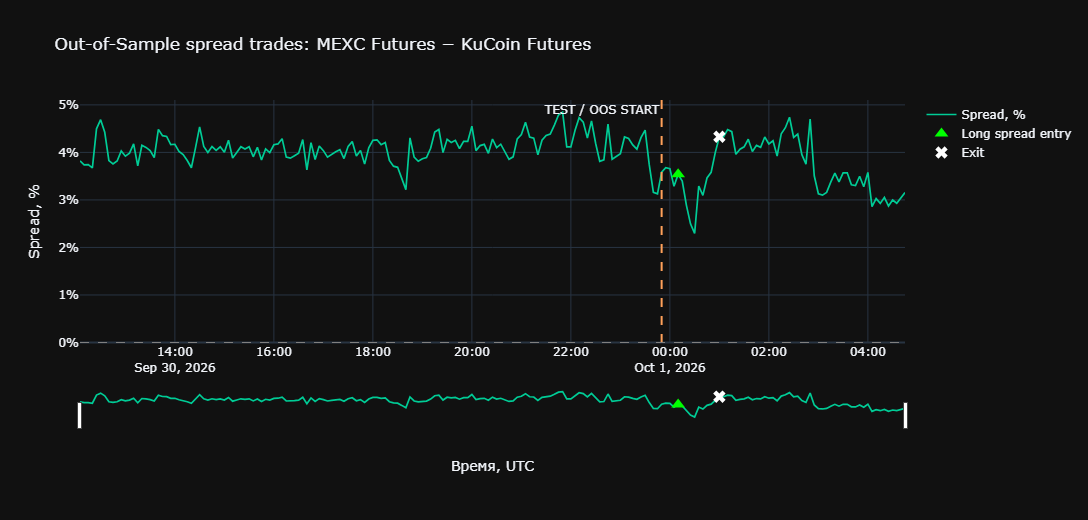

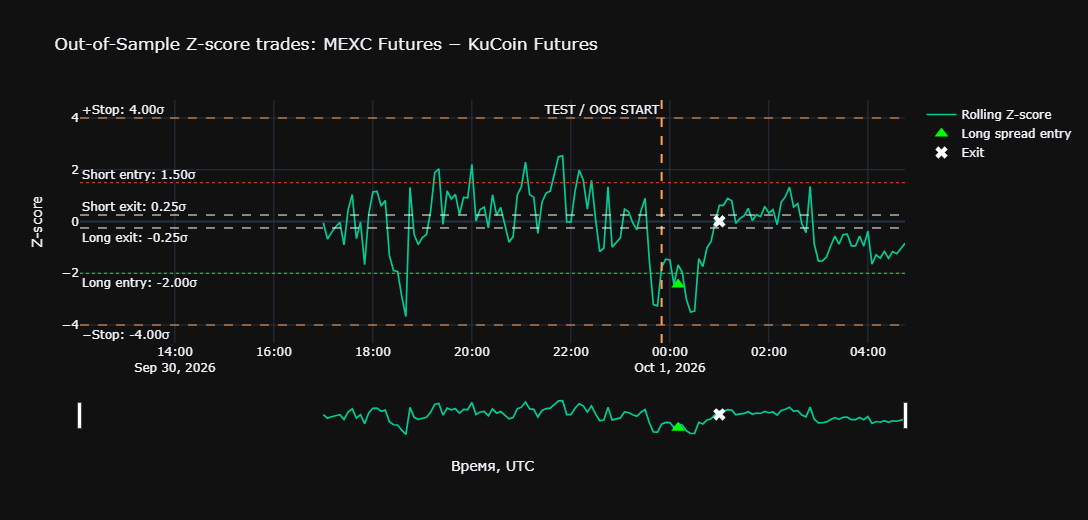


FINAL SUMMARY
Рынок 1: MEXC Futures
Рынок 2: KuCoin Futures

Fixed window: 60
Best train long entry: -2.00σ
Best train short entry: 1.50σ
Best train exit: 0.25σ

OOS trade count: 1
OOS Price PnL: 0.3778 USDT
OOS Funding PnL: 0.0389 USDT
OOS Fees + slippage: 0.1600 USDT
OOS Net PnL: 0.2567 USDT


In [16]:
# ============================================================
# CLEAN STAT-ARB BACKTEST
#
# Требуется уже работающий dashboard и:
#
# STATE["series"]
# STATE["markets"]
# STATE["selected_order"]
#
# Выбери два рынка в dashboard, например:
#
# MEXC Futures
# Bybit Futures
#
# Или:
#
# MEXC Spot
# MEXC Futures
#
# Эта ячейка:
#
# 1. Готовит данные.
# 2. Получает funding history.
# 3. Делит историю на TRAIN / TEST.
# 4. Подбирает только entry/exit Z-score на TRAIN.
# 5. Проверяет лучшую комбинацию на TEST.
# 6. Учитывает:
#    - price PnL;
#    - funding PnL;
#    - taker fees;
#    - slippage.
# 7. Строит графики spread и Z-score
#    с нанесёнными TEST-сделками.
#
# Window НЕ подбирается — он фиксированный.
# ============================================================

from itertools import product

import numpy as np
import pandas as pd
import plotly.graph_objects as go

from IPython.display import (
    HTML,
    display,
)


# ============================================================
# 1. НАСТРОЙКИ
# ============================================================

# Общий gross-notional пары.
#
# 100 USDT означает:
#
# 50 USDT — первая нога;
# 50 USDT — вторая нога.
GROSS_NOTIONAL_USDT = 100.0


# Оценочное проскальзывание на одну ногу.
#
# 5 bps = 0.05%.
SLIPPAGE_BPS_PER_LEG = 5.0


# Window не оптимизируется.
#
# При 5m:
# 60 свечей = 5 часов.
ZSCORE_WINDOW = 60


# Доля train-истории.
#
# Первые 70%:
# поиск параметров.
#
# Последние 30%:
# честный out-of-sample test.
TRAIN_FRACTION = 0.70


# Минимум сделок на TRAIN.
#
# Если на коротком участке нет минимум двух,
# код использует минимум одну сделку,
# но явно напишет предупреждение.
MIN_TRAIN_TRADES = 2


# ------------------------------------------------------------
# Entry / exit grid.
#
# 7 × 7 × 4 = 196 комбинаций.
# Это приемлемо.
# ------------------------------------------------------------

LONG_ENTRY_VALUES = [
    -0.50,
    -0.75,
    -1.00,
    -1.25,
    -1.50,
    -1.75,
    -2.00,
]

SHORT_ENTRY_VALUES = [
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    1.75,
    2.00,
]

EXIT_Z_VALUES = [
    0.00,
    0.25,
    0.50,
    0.75,
]


# Аварийный stop-Z.
STOP_Z = 4.0


# ============================================================
# 2. ПРОВЕРКА ВЫБРАННЫХ РЫНКОВ
# ============================================================

if len(STATE["selected_order"]) != 2:
    raise RuntimeError(
        "Сначала выбери ровно два рынка "
        "в основном dashboard."
    )

MARKET_A_NAME = STATE["selected_order"][0]
MARKET_B_NAME = STATE["selected_order"][1]

print("=" * 70)
print("SELECTED MARKETS")
print("=" * 70)

print("Рынок 1:", MARKET_A_NAME)
print("Рынок 2:", MARKET_B_NAME)

print(
    "\nНаправление spread:"
)

print(
    f"{MARKET_A_NAME} − {MARKET_B_NAME}"
)


# ============================================================
# 3. TAKER FEE
# ============================================================

def get_market_taker_fee(
    market_info,
    fallback=0.001,
):
    """
    Возвращает taker fee в долях единицы.

    0.001 = 0.10%.

    Источники:
    1. fetch_trading_fee;
    2. market['taker'];
    3. fallback.
    """
    exchange = make_exchange(
        exchange_id=market_info["exchange_id"],
        market_type=market_info["market_type"],
    )

    symbol = market_info["symbol"]

    try:
        exchange.load_markets()

        if exchange.has.get(
            "fetchTradingFee"
        ):
            fee_data = exchange.fetch_trading_fee(
                symbol
            )

            taker = fee_data.get("taker")

            if taker is not None:
                return float(taker)

    except Exception:
        pass

    try:
        exchange.load_markets()

        market = exchange.market(symbol)

        if market.get("taker") is not None:
            return float(market["taker"])

    except Exception:
        pass

    return float(fallback)


# ============================================================
# 4. FUNDING HISTORY
# ============================================================

def fetch_funding_events(
    market_info,
    start_timestamp,
    end_timestamp,
):
    """
    Загружает funding history.

    Для Spot:
        funding отсутствует -> пустая таблица.

    Для Futures:
        funding_timestamp
        funding_rate

    Funding начисляется только в timestamp,
    возвращённых API, а не на каждой свече.
    """
    empty = pd.DataFrame(
        columns=[
            "funding_timestamp",
            "funding_rate",
        ]
    )

    if market_info["market_type"] != "swap":
        return empty

    exchange = make_exchange(
        exchange_id=market_info["exchange_id"],
        market_type=market_info["market_type"],
    )

    if not exchange.has.get(
        "fetchFundingRateHistory"
    ):
        print(
            f"Funding history API недоступен: "
            f"{market_info['symbol']}"
        )

        return empty

    try:
        result = exchange.fetch_funding_rate_history(
            symbol=market_info["symbol"],
            since=int(start_timestamp),
            limit=1000,
        )

    except Exception as error:
        print(
            f"Funding warning: "
            f"{market_info['symbol']} | "
            f"{type(error).__name__}"
        )

        return empty

    if not result:
        return empty

    funding = pd.DataFrame(result)

    if (
        "timestamp" not in funding.columns
        or "fundingRate" not in funding.columns
    ):
        return empty

    funding = funding[
        [
            "timestamp",
            "fundingRate",
        ]
    ].copy()

    funding = funding.rename(
        columns={
            "timestamp": "funding_timestamp",
            "fundingRate": "funding_rate",
        }
    )

    funding["funding_rate"] = pd.to_numeric(
        funding["funding_rate"],
        errors="coerce",
    )

    funding = funding.dropna(
        subset=[
            "funding_timestamp",
            "funding_rate",
        ]
    )

    funding = funding[
        (
            funding["funding_timestamp"]
            >= int(start_timestamp)
        )
        & (
            funding["funding_timestamp"]
            <= int(end_timestamp)
        )
    ]

    funding = (
        funding
        .sort_values("funding_timestamp")
        .drop_duplicates(
            subset="funding_timestamp",
            keep="last",
        )
        .reset_index(drop=True)
    )

    return funding


# ============================================================
# 5. ПОДГОТОВКА ИСТОРИЧЕСКИХ ДАННЫХ
# ============================================================

def prepare_data(
    market_a_name,
    market_b_name,
):
    """
    Объединяет свечи двух выбранных рынков.

    Spread для стратегии:

        log(price_A) - log(price_B)

    Для одного token на двух рынках
    hedge ratio фиксирован как 1.

    Это важно:
    мы не оцениваем beta на всей истории,
    чтобы не использовать будущие данные.
    """
    df_a = STATE["series"][
        market_a_name
    ][
        [
            "timestamp",
            "datetime_utc",
            "close",
        ]
    ].copy()

    df_b = STATE["series"][
        market_b_name
    ][
        [
            "timestamp",
            "datetime_utc",
            "close",
        ]
    ].copy()

    data = (
        df_a.merge(
            df_b,
            on="timestamp",
            how="inner",
            suffixes=("_a", "_b"),
        )
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    if len(data) < ZSCORE_WINDOW + 60:
        raise RuntimeError(
            f"Недостаточно данных: {len(data)} свечей.\n"
            f"Нужно хотя бы "
            f"{ZSCORE_WINDOW + 60}."
        )

    data["spread_abs"] = (
        data["close_a"]
        - data["close_b"]
    )

    data["spread_pct"] = (
        (
            data["close_a"]
            / data["close_b"]
            - 1
        )
        * 100
    )

    data["log_spread"] = (
        np.log(data["close_a"])
        - np.log(data["close_b"])
    )

    market_a_info = STATE["markets"][
        market_a_name
    ]

    market_b_info = STATE["markets"][
        market_b_name
    ]

    start_timestamp = int(
        data["timestamp"].iloc[0]
    )

    end_timestamp = int(
        data["timestamp"].iloc[-1]
    )

    funding_a = fetch_funding_events(
        market_info=market_a_info,
        start_timestamp=start_timestamp,
        end_timestamp=end_timestamp,
    )

    funding_b = fetch_funding_events(
        market_info=market_b_info,
        start_timestamp=start_timestamp,
        end_timestamp=end_timestamp,
    )

    return (
        data,
        market_a_info,
        market_b_info,
        funding_a,
        funding_b,
    )


# ============================================================
# 6. ROLLING Z-SCORE
# ============================================================

def add_zscore(
    data,
    window,
):
    """
    Рассчитывает rolling Z-score.

    mean и std рассчитываются только
    на предыдущих и текущих свечах.
    """
    result = data.copy()

    result["rolling_mean"] = (
        result["log_spread"]
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

    result["rolling_std"] = (
        result["log_spread"]
        .rolling(
            window=window,
            min_periods=window,
        )
        .std(ddof=0)
    )

    result["z_score"] = (
        (
            result["log_spread"]
            - result["rolling_mean"]
        )
        / result["rolling_std"]
    )

    result = result.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    return result


# ============================================================
# 7. FUNDING PNL
# ============================================================

def funding_pnl_for_leg(
    funding_events,
    prices,

    price_column,

    quantity,
    position_sign,

    entry_timestamp,
    exit_timestamp,
):
    """
    Funding PnL одной ноги.

    position_sign:
        +1 = long;
        -1 = short.

    Positive funding:
        long платит;
        short получает.

    Формула:

        - position_sign
        * quantity
        * price_at_event
        * funding_rate
    """
    if funding_events.empty:
        return 0.0

    events = funding_events[
        (
            funding_events["funding_timestamp"]
            > entry_timestamp
        )
        & (
            funding_events["funding_timestamp"]
            <= exit_timestamp
        )
    ].copy()

    if events.empty:
        return 0.0

    price_df = prices[
        [
            "timestamp",
            price_column,
        ]
    ].copy()

    events = events.sort_values(
        "funding_timestamp"
    )

    price_df = price_df.sort_values(
        "timestamp"
    )

    events = pd.merge_asof(
        events,
        price_df,

        left_on="funding_timestamp",
        right_on="timestamp",

        direction="backward",
    )

    events = events.dropna(
        subset=[price_column]
    )

    pnl = (
        -position_sign
        * quantity
        * events[price_column]
        * events["funding_rate"]
    ).sum()

    return float(pnl)


# ============================================================
# 8. ЗАКРЫТИЕ СДЕЛКИ
# ============================================================

def close_trade(
    trade,
    data,
    exit_row,

    direction,

    funding_a,
    funding_b,

    entry_cost,
    exit_cost,
):
    """
    Унифицированный расчёт PnL закрытой сделки.
    """
    exit_timestamp = int(
        exit_row["timestamp"]
    )

    exit_price_a = float(
        exit_row["close_a"]
    )

    exit_price_b = float(
        exit_row["close_b"]
    )

    # LONG A / SHORT B.
    if direction == "long_spread":
        price_pnl_a = (
            trade["qty_a"]
            * (
                exit_price_a
                - trade["entry_price_a"]
            )
        )

        price_pnl_b = (
            trade["qty_b"]
            * (
                trade["entry_price_b"]
                - exit_price_b
            )
        )

        sign_a = +1
        sign_b = -1

    # SHORT A / LONG B.
    else:
        price_pnl_a = (
            trade["qty_a"]
            * (
                trade["entry_price_a"]
                - exit_price_a
            )
        )

        price_pnl_b = (
            trade["qty_b"]
            * (
                exit_price_b
                - trade["entry_price_b"]
            )
        )

        sign_a = -1
        sign_b = +1

    price_pnl = (
        price_pnl_a
        + price_pnl_b
    )

    funding_pnl_a = funding_pnl_for_leg(
        funding_events=funding_a,
        prices=data,

        price_column="close_a",

        quantity=trade["qty_a"],
        position_sign=sign_a,

        entry_timestamp=trade[
            "entry_timestamp"
        ],

        exit_timestamp=exit_timestamp,
    )

    funding_pnl_b = funding_pnl_for_leg(
        funding_events=funding_b,
        prices=data,

        price_column="close_b",

        quantity=trade["qty_b"],
        position_sign=sign_b,

        entry_timestamp=trade[
            "entry_timestamp"
        ],

        exit_timestamp=exit_timestamp,
    )

    funding_pnl = (
        funding_pnl_a
        + funding_pnl_b
    )

    total_cost = (
        entry_cost
        + exit_cost
    )

    net_pnl = (
        price_pnl
        + funding_pnl
        - total_cost
    )

    return {
        "exit_timestamp": exit_timestamp,

        "exit_time": exit_row[
            "datetime_utc_a"
        ],

        "exit_price_a": exit_price_a,
        "exit_price_b": exit_price_b,

        "price_pnl_a_usdt": price_pnl_a,
        "price_pnl_b_usdt": price_pnl_b,

        "price_pnl_usdt": price_pnl,

        "funding_pnl_a_usdt": funding_pnl_a,
        "funding_pnl_b_usdt": funding_pnl_b,

        "funding_pnl_usdt": funding_pnl,

        "total_cost_usdt": total_cost,

        "net_pnl_usdt": net_pnl,
    }


# ============================================================
# 9. BACKTEST
# ============================================================

def run_backtest(
    raw_data,

    funding_a,
    funding_b,

    fee_rate_a,
    fee_rate_b,

    long_entry_z,
    short_entry_z,

    exit_z,
    stop_z,

    trade_start_index,
    trade_end_index,

    gross_notional_usdt,
    slippage_bps_per_leg,
):
    """
    Запускает backtest только на участке:

        trade_start_index ... trade_end_index

    Z-score строится на всей доступной истории,
    чтобы test-отрезок имел history warmup.

    Но сделки открываются только начиная
    с trade_start_index.

    Это нужно для честного OOS test.
    """
    data = add_zscore(
        data=raw_data,
        window=ZSCORE_WINDOW,
    ).reset_index(drop=True)

    leg_notional = (
        gross_notional_usdt / 2
    )

    slippage_rate = (
        slippage_bps_per_leg / 10_000
    )

    entry_cost = (
        leg_notional
        * (
            fee_rate_a
            + slippage_rate
        )
        + leg_notional
        * (
            fee_rate_b
            + slippage_rate
        )
    )

    exit_cost = (
        leg_notional
        * (
            fee_rate_a
            + slippage_rate
        )
        + leg_notional
        * (
            fee_rate_b
            + slippage_rate
        )
    )

    trades = []

    position = None
    open_trade = None

    start_index = max(
        ZSCORE_WINDOW,
        trade_start_index,
    )

    # Нужна следующая свеча для исполнения.
    end_index = min(
        trade_end_index,
        len(data) - 1,
    )

    for i in range(
        start_index,
        end_index,
    ):
        signal_row = data.iloc[i]
        fill_row = data.iloc[i + 1]

        z = signal_row["z_score"]

        if pd.isna(z):
            continue

        # ----------------------------------------------------
        # ENTRY
        # ----------------------------------------------------

        if position is None:
            # LONG A / SHORT B.
            if z <= long_entry_z:
                position = "long_spread"

                open_trade = {
                    "direction": position,

                    "entry_i": i + 1,

                    "entry_timestamp": int(
                        fill_row["timestamp"]
                    ),

                    "entry_time": fill_row[
                        "datetime_utc_a"
                    ],

                    "entry_z": float(z),

                    "entry_price_a": float(
                        fill_row["close_a"]
                    ),

                    "entry_price_b": float(
                        fill_row["close_b"]
                    ),

                    "qty_a": (
                        leg_notional
                        / float(fill_row["close_a"])
                    ),

                    "qty_b": (
                        leg_notional
                        / float(fill_row["close_b"])
                    ),
                }

            # SHORT A / LONG B.
            elif z >= short_entry_z:
                position = "short_spread"

                open_trade = {
                    "direction": position,

                    "entry_i": i + 1,

                    "entry_timestamp": int(
                        fill_row["timestamp"]
                    ),

                    "entry_time": fill_row[
                        "datetime_utc_a"
                    ],

                    "entry_z": float(z),

                    "entry_price_a": float(
                        fill_row["close_a"]
                    ),

                    "entry_price_b": float(
                        fill_row["close_b"]
                    ),

                    "qty_a": (
                        leg_notional
                        / float(fill_row["close_a"])
                    ),

                    "qty_b": (
                        leg_notional
                        / float(fill_row["close_b"])
                    ),
                }

            continue

        # ----------------------------------------------------
        # EXIT RULES
        # ----------------------------------------------------

        should_exit = False
        exit_reason = None

        if position == "long_spread":
            # Например:
            #
            # long entry = -1.5
            # exit_z = 0.5
            #
            # выход при z >= -0.5.
            if z >= -exit_z:
                should_exit = True
                exit_reason = "mean_reversion"

            elif z <= -stop_z:
                should_exit = True
                exit_reason = "stop_z"

        else:
            # short entry = +1.5
            # exit_z = 0.5
            #
            # выход при z <= +0.5.
            if z <= exit_z:
                should_exit = True
                exit_reason = "mean_reversion"

            elif z >= stop_z:
                should_exit = True
                exit_reason = "stop_z"

        if not should_exit:
            continue

        close_result = close_trade(
            trade=open_trade,
            data=data,
            exit_row=fill_row,

            direction=position,

            funding_a=funding_a,
            funding_b=funding_b,

            entry_cost=entry_cost,
            exit_cost=exit_cost,
        )

        trades.append({
            **open_trade,

            **close_result,

            "exit_z": float(z),

            "holding_bars": (
                i + 1
                - open_trade["entry_i"]
            ),

            "exit_reason": exit_reason,

            "return_percent": (
                close_result["net_pnl_usdt"]
                / gross_notional_usdt
                * 100
            ),
        })

        position = None
        open_trade = None

    # --------------------------------------------------------
    # Закрываем позицию в конце тестируемого участка.
    # --------------------------------------------------------

    if position is not None:
        final_row = data.iloc[
            trade_end_index
        ]

        close_result = close_trade(
            trade=open_trade,
            data=data,
            exit_row=final_row,

            direction=position,

            funding_a=funding_a,
            funding_b=funding_b,

            entry_cost=entry_cost,
            exit_cost=exit_cost,
        )

        trades.append({
            **open_trade,

            **close_result,

            "exit_z": float(
                final_row["z_score"]
            ),

            "holding_bars": (
                trade_end_index
                - open_trade["entry_i"]
            ),

            "exit_reason": "forced_end_of_segment",

            "return_percent": (
                close_result["net_pnl_usdt"]
                / gross_notional_usdt
                * 100
            ),
        })

    trades_df = pd.DataFrame(trades)

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    if trades_df.empty:
        metrics = {
            "trade_count": 0,

            "net_pnl_usdt": 0.0,
            "price_pnl_usdt": 0.0,
            "funding_pnl_usdt": 0.0,
            "cost_usdt": 0.0,

            "win_rate_percent": 0.0,
            "profit_factor": 0.0,

            "max_drawdown_usdt": 0.0,

            "average_trade_pnl_usdt": 0.0,
            "average_holding_bars": 0.0,
        }

        return data, trades_df, metrics

    equity = trades_df[
        "net_pnl_usdt"
    ].cumsum()

    drawdown = (
        equity
        - equity.cummax()
    )

    gross_profit = trades_df[
        trades_df["net_pnl_usdt"] > 0
    ]["net_pnl_usdt"].sum()

    gross_loss = abs(
        trades_df[
            trades_df["net_pnl_usdt"] < 0
        ]["net_pnl_usdt"].sum()
    )

    profit_factor = (
        gross_profit / gross_loss
        if gross_loss > 0
        else np.inf
    )

    metrics = {
        "trade_count": len(trades_df),

        "net_pnl_usdt": float(
            trades_df["net_pnl_usdt"].sum()
        ),

        "price_pnl_usdt": float(
            trades_df["price_pnl_usdt"].sum()
        ),

        "funding_pnl_usdt": float(
            trades_df["funding_pnl_usdt"].sum()
        ),

        "cost_usdt": float(
            trades_df["total_cost_usdt"].sum()
        ),

        "win_rate_percent": float(
            (
                trades_df["net_pnl_usdt"] > 0
            ).mean()
            * 100
        ),

        "profit_factor": float(
            profit_factor
        ),

        "max_drawdown_usdt": float(
            drawdown.min()
        ),

        "average_trade_pnl_usdt": float(
            trades_df["net_pnl_usdt"].mean()
        ),

        "average_holding_bars": float(
            trades_df["holding_bars"].mean()
        ),
    }

    return data, trades_df, metrics


# ============================================================
# 10. OPTIMIZATION НА TRAIN
# ============================================================

def optimize_train_parameters(
    raw_data,

    funding_a,
    funding_b,

    fee_rate_a,
    fee_rate_b,

    train_end_index,
):
    """
    Подбирает entry/exit параметры
    только на train-отрезке.

    Window фиксирован.
    """
    rows = []
    errors = []

    for (
        long_entry_z,
        short_entry_z,
        exit_z,
    ) in product(
        LONG_ENTRY_VALUES,
        SHORT_ENTRY_VALUES,
        EXIT_Z_VALUES,
    ):
        try:
            _, _, metrics = run_backtest(
                raw_data=raw_data,

                funding_a=funding_a,
                funding_b=funding_b,

                fee_rate_a=fee_rate_a,
                fee_rate_b=fee_rate_b,

                long_entry_z=long_entry_z,
                short_entry_z=short_entry_z,

                exit_z=exit_z,
                stop_z=STOP_Z,

                trade_start_index=ZSCORE_WINDOW,
                trade_end_index=train_end_index,

                gross_notional_usdt=GROSS_NOTIONAL_USDT,

                slippage_bps_per_leg=SLIPPAGE_BPS_PER_LEG,
            )

            rows.append({
                "long_entry_z": long_entry_z,
                "short_entry_z": short_entry_z,

                "exit_z": exit_z,
                "stop_z": STOP_Z,

                **metrics,
            })

        except Exception as error:
            errors.append({
                "long_entry_z": long_entry_z,
                "short_entry_z": short_entry_z,
                "exit_z": exit_z,

                "error_type": type(error).__name__,
                "error_text": str(error),
            })

    if not rows:
        errors_df = pd.DataFrame(errors)

        display(errors_df.head(20))

        raise RuntimeError(
            "Все комбинации TRAIN упали с ошибкой."
        )

    result = pd.DataFrame(rows)

    print(
        f"Всего комбинаций: {len(result)}"
    )

    print(
        f"Комбинаций с >= 1 сделкой: "
        f"{int((result['trade_count'] >= 1).sum())}"
    )

    print(
        f"Комбинаций с >= {MIN_TRAIN_TRADES} сделками: "
        f"{int((result['trade_count'] >= MIN_TRAIN_TRADES).sum())}"
    )

    # Предпочитаем минимум MIN_TRAIN_TRADES.
    filtered = result[
        result["trade_count"]
        >= MIN_TRAIN_TRADES
    ].copy()

    # Fallback для короткой истории.
    if filtered.empty:
        print(
            "\nПредупреждение: "
            "нет комбинаций с нужным количеством сделок."
        )

        print(
            "Используются комбинации с минимум одной сделкой."
        )

        filtered = result[
            result["trade_count"] >= 1
        ].copy()

    # Если сделок нет вообще.
    if filtered.empty:
        print(
            "\nВнимание: "
            "ни одна комбинация не открыла сделку."
        )

        filtered = result.copy()

    # Ranking только по TRAIN.
    filtered = (
        filtered
        .sort_values(
            by=[
                "net_pnl_usdt",
                "profit_factor",
                "max_drawdown_usdt",
                "trade_count",
            ],

            ascending=[
                False,
                False,
                False,
                False,
            ],
        )
        .reset_index(drop=True)
    )

    filtered.attrs["all_train_results"] = result
    filtered.attrs["errors"] = pd.DataFrame(errors)

    return filtered


# ============================================================
# 11. ГРАФИК SPREAD + TEST-СДЕЛКИ
# ============================================================

def plot_spread_with_trades(
    data,
    trades,

    market_a_name,
    market_b_name,

    test_start_time,
):
    fig = go.Figure()

    # Визуально отделяем train от test.
    fig.add_vline(
        x=test_start_time,

        line_color="#FFA15A",
        line_width=2,
        line_dash="dash",

        annotation_text="TEST / OOS START",
        annotation_position="top left",
    )

    fig.add_trace(
        go.Scatter(
            x=data["datetime_utc_a"],
            y=data["spread_pct"],

            mode="lines",

            name="Spread, %",

            line=dict(
                color="#00CC96",
                width=1.7,
            ),

            hovertemplate=(
                "<b>%{x}</b><br>"
                "Spread: %{y:.6f}%"
                "<extra></extra>"
            ),
        )
    )

    fig.add_hline(
        y=0,
        line_color="gray",
        line_dash="dash",
        line_width=1,
    )

    if not trades.empty:
        long_entries = trades[
            trades["direction"] == "long_spread"
        ]

        short_entries = trades[
            trades["direction"] == "short_spread"
        ]

        if not long_entries.empty:
            long_spread = (
                (
                    long_entries["entry_price_a"]
                    / long_entries["entry_price_b"]
                    - 1
                )
                * 100
            )

            fig.add_trace(
                go.Scatter(
                    x=long_entries["entry_time"],
                    y=long_spread,

                    mode="markers",

                    name="Long spread entry",

                    marker=dict(
                        symbol="triangle-up",
                        size=12,
                        color="#00FF00",
                    ),
                )
            )

        if not short_entries.empty:
            short_spread = (
                (
                    short_entries["entry_price_a"]
                    / short_entries["entry_price_b"]
                    - 1
                )
                * 100
            )

            fig.add_trace(
                go.Scatter(
                    x=short_entries["entry_time"],
                    y=short_spread,

                    mode="markers",

                    name="Short spread entry",

                    marker=dict(
                        symbol="triangle-down",
                        size=12,
                        color="#FF3B30",
                    ),
                )
            )

        exit_spread = (
            (
                trades["exit_price_a"]
                / trades["exit_price_b"]
                - 1
            )
            * 100
        )

        fig.add_trace(
            go.Scatter(
                x=trades["exit_time"],
                y=exit_spread,

                mode="markers",

                name="Exit",

                marker=dict(
                    symbol="x",
                    color="white",
                    size=11,
                ),

                customdata=trades[
                    [
                        "net_pnl_usdt",
                        "price_pnl_usdt",
                        "funding_pnl_usdt",
                        "total_cost_usdt",
                    ]
                ].to_numpy(),

                hovertemplate=(
                    "<b>EXIT</b><br>"
                    "Время: %{x}<br>"
                    "Spread: %{y:.6f}%<br>"
                    "Net PnL: %{customdata[0]:.4f} USDT<br>"
                    "Price PnL: %{customdata[1]:.4f} USDT<br>"
                    "Funding PnL: %{customdata[2]:.4f} USDT<br>"
                    "Costs: %{customdata[3]:.4f} USDT"
                    "<extra></extra>"
                ),
            )
        )

    fig.update_layout(
        title=(
            f"Out-of-Sample spread trades: "
            f"{market_a_name} − {market_b_name}"
        ),

        template="plotly_dark",

        height=520,

        dragmode="pan",
        hovermode="x unified",

        xaxis=dict(
            title="Время, UTC",
            rangeslider=dict(
                visible=True,
            ),
        ),

        yaxis=dict(
            title="Spread, %",
            ticksuffix="%",
        ),
    )

    return fig


# ============================================================
# 12. ГРАФИК Z-SCORE + TEST-СДЕЛКИ
# ============================================================

def plot_zscore_with_trades(
    data,
    trades,

    market_a_name,
    market_b_name,

    long_entry_z,
    short_entry_z,

    exit_z,
    stop_z,

    test_start_time,
):
    fig = go.Figure()

    fig.add_vline(
        x=test_start_time,

        line_color="#FFA15A",
        line_width=2,
        line_dash="dash",

        annotation_text="TEST / OOS START",
        annotation_position="top left",
    )

    fig.add_trace(
        go.Scatter(
            x=data["datetime_utc_a"],
            y=data["z_score"],

            mode="lines",

            name="Rolling Z-score",

            line=dict(
                color="#00CC96",
                width=1.7,
            ),

            hovertemplate=(
                "<b>%{x}</b><br>"
                "Z-score: %{y:.4f}"
                "<extra></extra>"
            ),
        )
    )

    fig.add_hline(
        y=-exit_z,

        line_color="white",
        line_dash="dash",
        line_width=1,

        annotation_text=(
            f"Long exit: {-exit_z:.2f}σ"
        ),

        annotation_position="bottom left",
    )

    fig.add_hline(
        y=exit_z,

        line_color="white",
        line_dash="dash",
        line_width=1,

        annotation_text=(
            f"Short exit: {exit_z:.2f}σ"
        ),

        annotation_position="top left",
    )

    fig.add_hline(
        y=long_entry_z,

        line_color="#00FF00",
        line_dash="dot",
        line_width=1,

        annotation_text=(
            f"Long entry: {long_entry_z:.2f}σ"
        ),

        annotation_position="bottom left",
    )

    fig.add_hline(
        y=short_entry_z,

        line_color="#FF3B30",
        line_dash="dot",
        line_width=1,

        annotation_text=(
            f"Short entry: {short_entry_z:.2f}σ"
        ),

        annotation_position="top left",
    )

    fig.add_hline(
        y=stop_z,

        line_color="#FFA15A",
        line_dash="dash",
        line_width=1,

        annotation_text=f"+Stop: {stop_z:.2f}σ",
        annotation_position="top left",
    )

    fig.add_hline(
        y=-stop_z,

        line_color="#FFA15A",
        line_dash="dash",
        line_width=1,

        annotation_text=f"−Stop: {-stop_z:.2f}σ",
        annotation_position="bottom left",
    )

    if not trades.empty:
        long_entries = trades[
            trades["direction"] == "long_spread"
        ]

        short_entries = trades[
            trades["direction"] == "short_spread"
        ]

        if not long_entries.empty:
            fig.add_trace(
                go.Scatter(
                    x=long_entries["entry_time"],
                    y=long_entries["entry_z"],

                    mode="markers",

                    name="Long spread entry",

                    marker=dict(
                        symbol="triangle-up",
                        size=12,
                        color="#00FF00",
                    ),
                )
            )

        if not short_entries.empty:
            fig.add_trace(
                go.Scatter(
                    x=short_entries["entry_time"],
                    y=short_entries["entry_z"],

                    mode="markers",

                    name="Short spread entry",

                    marker=dict(
                        symbol="triangle-down",
                        size=12,
                        color="#FF3B30",
                    ),
                )
            )

        fig.add_trace(
            go.Scatter(
                x=trades["exit_time"],
                y=trades["exit_z"],

                mode="markers",

                name="Exit",

                marker=dict(
                    symbol="x",
                    color="white",
                    size=11,
                ),

                customdata=trades[
                    [
                        "net_pnl_usdt",
                        "funding_pnl_usdt",
                        "exit_reason",
                    ]
                ].to_numpy(),

                hovertemplate=(
                    "<b>EXIT</b><br>"
                    "Время: %{x}<br>"
                    "Z-score: %{y:.4f}<br>"
                    "Net PnL: %{customdata[0]:.4f} USDT<br>"
                    "Funding PnL: %{customdata[1]:.4f} USDT<br>"
                    "Reason: %{customdata[2]}"
                    "<extra></extra>"
                ),
            )
        )

    fig.update_layout(
        title=(
            f"Out-of-Sample Z-score trades: "
            f"{market_a_name} − {market_b_name}"
        ),

        template="plotly_dark",

        height=520,

        dragmode="pan",
        hovermode="x unified",

        xaxis=dict(
            title="Время, UTC",
            rangeslider=dict(
                visible=True,
            ),
        ),

        yaxis=dict(
            title="Z-score",
        ),
    )

    return fig


# ============================================================
# 13. ПОДГОТОВКА ДАННЫХ И FUNDING
# ============================================================

(
    raw_data,
    market_a_info,
    market_b_info,
    funding_a,
    funding_b,
) = prepare_data(
    market_a_name=MARKET_A_NAME,
    market_b_name=MARKET_B_NAME,
)

fee_rate_a = get_market_taker_fee(
    market_a_info
)

fee_rate_b = get_market_taker_fee(
    market_b_info
)

print("\n" + "=" * 70)
print("DATA SUMMARY")
print("=" * 70)

print(
    "Синхронизировано свечей:",
    len(raw_data),
)

print(
    "Начало:",
    raw_data["datetime_utc_a"].iloc[0],
)

print(
    "Конец:",
    raw_data["datetime_utc_a"].iloc[-1],
)

print(
    "Фиксированный Z-score window:",
    ZSCORE_WINDOW,
)

print(
    f"\nFunding events Рынок 1: "
    f"{len(funding_a)}"
)

print(
    f"Funding events Рынок 2: "
    f"{len(funding_b)}"
)

print(
    f"\nTaker fee Рынок 1: "
    f"{fee_rate_a * 100:.4f}%"
)

print(
    f"Taker fee Рынок 2: "
    f"{fee_rate_b * 100:.4f}%"
)

print(
    f"\nGross notional: "
    f"{GROSS_NOTIONAL_USDT:.2f} USDT"
)

print(
    f"Slippage / leg: "
    f"{SLIPPAGE_BPS_PER_LEG:.2f} bps"
)


# ============================================================
# 14. TRAIN / TEST SPLIT
# ============================================================

split_index = int(
    len(raw_data)
    * TRAIN_FRACTION
)

# Защита от слишком маленького test.
split_index = max(
    split_index,
    ZSCORE_WINDOW + 30,
)

split_index = min(
    split_index,
    len(raw_data) - 30,
)

train_start_time = raw_data[
    "datetime_utc_a"
].iloc[0]

train_end_time = raw_data[
    "datetime_utc_a"
].iloc[split_index - 1]

test_start_time = raw_data[
    "datetime_utc_a"
].iloc[split_index]

test_end_time = raw_data[
    "datetime_utc_a"
].iloc[-1]

print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print(
    f"TRAIN candles: {split_index}"
)

print(
    f"TEST candles: "
    f"{len(raw_data) - split_index}"
)

print(
    f"\nTRAIN:"
)

print(
    f"{train_start_time} "
    f"→ {train_end_time}"
)

print(
    f"\nTEST / OOS:"
)

print(
    f"{test_start_time} "
    f"→ {test_end_time}"
)


# ============================================================
# 15. TRAIN OPTIMIZATION
# ============================================================

print("\n" + "=" * 70)
print("TRAIN OPTIMIZATION")
print("=" * 70)

print(
    "Подбор производится только на TRAIN."
)

print(
    "Window фиксирован и не подбирается."
)

print(
    "Всего комбинаций:",
    len(LONG_ENTRY_VALUES)
    * len(SHORT_ENTRY_VALUES)
    * len(EXIT_Z_VALUES),
)

train_optimization = optimize_train_parameters(
    raw_data=raw_data,

    funding_a=funding_a,
    funding_b=funding_b,

    fee_rate_a=fee_rate_a,
    fee_rate_b=fee_rate_b,

    train_end_index=split_index,
)

display(
    train_optimization.head(25)
)


# ============================================================
# 16. ЛУЧШИЕ TRAIN-ПАРАМЕТРЫ
# ============================================================

best_parameters = train_optimization.iloc[0]

print("\n" + "=" * 70)
print("BEST TRAIN PARAMETERS")
print("=" * 70)

display(
    best_parameters.to_frame(
        name="value"
    )
)


# ============================================================
# 17. ЧЕСТНЫЙ OUT-OF-SAMPLE TEST
# ============================================================

(
    test_data,
    test_trades,
    test_metrics,
) = run_backtest(
    raw_data=raw_data,

    funding_a=funding_a,
    funding_b=funding_b,

    fee_rate_a=fee_rate_a,
    fee_rate_b=fee_rate_b,

    long_entry_z=float(
        best_parameters["long_entry_z"]
    ),

    short_entry_z=float(
        best_parameters["short_entry_z"]
    ),

    exit_z=float(
        best_parameters["exit_z"]
    ),

    stop_z=float(
        best_parameters["stop_z"]
    ),

    # Стартовать с test-части.
    trade_start_index=split_index,

    # Закончить на последней свече.
    trade_end_index=len(raw_data) - 1,

    gross_notional_usdt=GROSS_NOTIONAL_USDT,

    slippage_bps_per_leg=SLIPPAGE_BPS_PER_LEG,
)

print("\n" + "=" * 70)
print("OUT-OF-SAMPLE TEST METRICS")
print("=" * 70)

display(
    pd.Series(
        test_metrics
    ).to_frame(
        name="value"
    )
)


# ============================================================
# 18. ИНТЕРПРЕТАЦИЯ TEST
# ============================================================

if test_metrics["trade_count"] == 0:
    oos_comment = """
    <b style="color:#FFA15A">
    На test-отрезке нет сделок.
    </b>
    <br>
    Это не означает прибыльность или убыточность.
    На данной короткой истории стратегия не получила сигнала.
    """

elif test_metrics["net_pnl_usdt"] > 0:
    oos_comment = f"""
    <b style="color:#00CC96">
    OOS Test PnL положительный:
    {test_metrics["net_pnl_usdt"]:.4f} USDT.
    </b>
    <br>
    Но результат нельзя считать доказательством edge,
    если сделок мало.
    """

else:
    oos_comment = f"""
    <b style="color:#EF553B">
    OOS Test PnL отрицательный:
    {test_metrics["net_pnl_usdt"]:.4f} USDT.
    </b>
    <br>
    Это означает, что лучшие параметры train
    не подтвердились на test-отрезке.
    """

display(
    HTML(
        f"""
        <hr>

        <h3>Интерпретация out-of-sample test</h3>

        <p>
        {oos_comment}
        </p>

        <p>
        <b>Trade count:</b>
        {test_metrics["trade_count"]}
        </p>

        <p>
        <b>Price PnL:</b>
        {test_metrics["price_pnl_usdt"]:.4f} USDT
        </p>

        <p>
        <b>Funding PnL:</b>
        {test_metrics["funding_pnl_usdt"]:.4f} USDT
        </p>

        <p>
        <b>Fees + slippage:</b>
        {test_metrics["cost_usdt"]:.4f} USDT
        </p>

        <p>
        <b>Net PnL:</b>
        {test_metrics["net_pnl_usdt"]:.4f} USDT
        </p>
        """
    )
)


# ============================================================
# 19. ГРАФИК SPREAD + TEST-СДЕЛКИ
# ============================================================

spread_figure = plot_spread_with_trades(
    data=test_data,
    trades=test_trades,

    market_a_name=MARKET_A_NAME,
    market_b_name=MARKET_B_NAME,

    test_start_time=test_start_time,
)

spread_figure.show(
    config={
        "scrollZoom": True,
        "displaylogo": False,
        "responsive": True,
    }
)


# ============================================================
# 20. ГРАФИК Z-SCORE + TEST-СДЕЛКИ
# ============================================================

zscore_figure = plot_zscore_with_trades(
    data=test_data,
    trades=test_trades,

    market_a_name=MARKET_A_NAME,
    market_b_name=MARKET_B_NAME,

    long_entry_z=float(
        best_parameters["long_entry_z"]
    ),

    short_entry_z=float(
        best_parameters["short_entry_z"]
    ),

    exit_z=float(
        best_parameters["exit_z"]
    ),

    stop_z=float(
        best_parameters["stop_z"]
    ),

    test_start_time=test_start_time,
)

zscore_figure.show(
    config={
        "scrollZoom": True,
        "displaylogo": False,
        "responsive": True,
    }
)


# ============================================================
# 21. ИТОГ
# ============================================================

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(
    "Рынок 1:",
    MARKET_A_NAME,
)

print(
    "Рынок 2:",
    MARKET_B_NAME,
)

print(
    f"\nFixed window: "
    f"{ZSCORE_WINDOW}"
)

print(
    f"Best train long entry: "
    f"{best_parameters['long_entry_z']:.2f}σ"
)

print(
    f"Best train short entry: "
    f"{best_parameters['short_entry_z']:.2f}σ"
)

print(
    f"Best train exit: "
    f"{best_parameters['exit_z']:.2f}σ"
)

print(
    f"\nOOS trade count: "
    f"{test_metrics['trade_count']}"
)

print(
    f"OOS Price PnL: "
    f"{test_metrics['price_pnl_usdt']:.4f} USDT"
)

print(
    f"OOS Funding PnL: "
    f"{test_metrics['funding_pnl_usdt']:.4f} USDT"
)

print(
    f"OOS Fees + slippage: "
    f"{test_metrics['cost_usdt']:.4f} USDT"
)

print(
    f"OOS Net PnL: "
    f"{test_metrics['net_pnl_usdt']:.4f} USDT"
)

In [22]:
!git add . && git commit -m "checkpoint" && git push

SyntaxError: invalid syntax (1307727110.py, line 1)

In [ ]:
!git add cross_exchange_statarb_dashboard_ranked.py
!git commit -m "feat: add automatic stat-arb pair ranking"
git push